# Visualize all the evaluations results


## Perplexity evaluation


In [1]:
## IMPORT
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb

### Helper functions


In [2]:
def get_df_domain(domain, results_path):
    # Load the results
    with open(results_path, "r") as file:
        data = json.load(file)

    # Convert to DataFrame
    df = pd.DataFrame(data[domain])
    return df

def comparison_perplexity_domains_with_HMM_only_realistic_data(
    domains,
    results_PC_file,
    results_PCFG_file,
    results_LLM_file,
    results_PC_HMM_file,
    seeds_info_file,
    use_computed_realistic=True,  # if False, uses "realistic_max_length" instead
):
    """
    Compare perplexity across domains for the realistic max length only.

    Args:
        domains: list of domain names.
        results_*_file: JSON or CSV paths for each model (loaded by get_df_domain()).
        seeds_info_file: path to JSON containing per-domain realistic lengths.
        use_computed_realistic: whether to use "computed_realistic_snapped" (True)
                                or "realistic_max_length" (False).
    """
    import json

    # --- Load seeds info
    with open(seeds_info_file, "r") as f:
        seeds_data = json.load(f)

    # Extract mapping domain -> realistic length
    realistic_map = {}
    for domain, entries in seeds_data.items():
        if not entries:
            continue
        # If multiple entries, pick the first (or we could average, but you can change this)
        # val = (
        #     entries[0].get("computed_realistic_max_length")
        #     if use_computed_realistic
        #     else entries[0].get("realistic_max_length")
        # )

        val = (
            entries[0].get("maximum_max_length_available")
            if use_computed_realistic
            else entries[0].get("realistic_max_length")
        )
        realistic_map[domain] = int(val) if val is not None else None
    # --- Gather all results
    all_data = []

    for domain in domains:
        df_PC = get_df_domain(domain, results_PC_file)
        df_PC["method"] = "PC (ExplainFuzz)"
        df_PCFG = get_df_domain(domain, results_PCFG_file)
        df_PCFG["method"] = "PCFG"
        df_PC_HMM = get_df_domain(domain, results_PC_HMM_file)
        df_PC_HMM["method"] = "PC (HMM)"

        # If you later re-add LLM results
        df_LLM = get_df_domain(domain, results_LLM_file)
        df_LLM["method"] = "LLM"

        # Concatenate all models for this domain
        df_domain_all = pd.concat([df_PC, df_PC_HMM, df_PCFG,df_LLM], ignore_index=True)

        # --- Filter by realistic max length
        realistic_len = realistic_map.get(domain)
        if realistic_len is not None:
            df_domain_all = df_domain_all[df_domain_all["max_length"] == realistic_len]
        else:
            print(f"⚠️ No realistic max length found for {domain}, keeping all lengths.")

        all_data.append(df_domain_all)

    # --- Combine all domains
    df_all = pd.concat(all_data, ignore_index=True)

    # --- Keep only 'no-generate' mode
    df_filtered = df_all[df_all["mode"] == "no-generate"]

    # --- Plot
    # palette = sns.color_palette()
    # colors = {
    #     "PC (ExplainFuzz)": palette[0],
    #     "PCFG": palette[1],
    #     "LLM": palette[2],
    #     "PC (HMM)": palette[3],
    # }

    # plt.figure(figsize=(12, 6))
    # sns.barplot(
    #     data=df_filtered,
    #     x="domain",
    #     y="perplexity",
    #     hue="method",
    #     errorbar="sd",
    #     palette=colors,
    # )
    # plt.title("Perplexity Across Domains", fontsize=18)
    # plt.xlabel("Domain", fontsize=18)
    # plt.ylabel("Perplexity", fontsize=18)
    # plt.xticks(fontsize=16)
    # plt.tight_layout()
    # plt.legend(title="Method", title_fontsize=14, fontsize=14)
    # # plt.show()

    return df_filtered


def df_filtered_to_latex_table(df_filtered, caption="Perplexity per Domain (Maximum Length available)", label="tab:perplexity"):
    """
    Convert a filtered DataFrame (one entry per domain-method) to a LaTeX table.

    Parameters:
    - df_filtered: DataFrame with columns ['domain', 'method', 'perplexity']
    - caption: Table caption
    - label: LaTeX label

    Returns:
    - LaTeX table as a string
    """

    # Pivot the perplexity table
    pivot = df_filtered.pivot(index="domain", columns="method", values="perplexity").round(2)
    pivot = pivot.applymap(lambda x: f"{x:.2f}")

    # Reorder methods
    methods_order = ["LLM", "PCFG", "PC (HMM)", "PC (ExplainFuzz)"]
    pivot = pivot[[m for m in methods_order if m in pivot.columns]]

    # Add max_length column (just take first value per domain)
    max_length_per_domain = df_filtered.groupby("domain")["max_length"].first()
    pivot["max_length"] = pivot.index.map(max_length_per_domain)

    # Bold the best (lowest) perplexity per domain
    for domain in pivot.index:
        row = pivot.loc[domain, methods_order]  # only method columns
        best_method = row.astype(float).idxmin()
        pivot.loc[domain, best_method] = f"\\textbf{{{row[best_method]}}}"

    # Optionally, move max_length to the first column
    pivot = pivot[["max_length"] + [m for m in methods_order if m in pivot.columns]]

    # Generate LaTeX code
    latex_table = pivot.to_latex(
        escape=False,
        caption=caption,
        label=label,
        column_format="l" + "c" * len(pivot.columns),
        multicolumn=True,
        multicolumn_format="c",
)
    return latex_table


In [3]:
def compare_results_model(
    domain,
    results_PC_file,
    results_PCFG_file,
    results_LLM_file,
    results_seeds_file,
    results_PC_HMM_file=None,
):
    df_PC = get_df_domain(domain, results_PC_file)
    df_PC["method"] = "PC (ExplainFuzz)"
    df_PCFG = get_df_domain(domain, results_PCFG_file)
    # df_LLM = get_df_domain(domain, results_LLM_file)
    if results_PC_HMM_file:
        df_PC_HMM = get_df_domain(domain, results_PC_HMM_file)
    df_seeds = get_df_domain(domain, results_seeds_file)
    if results_PC_HMM_file:
        df = pd.concat([df_PC, df_PCFG, df_PC_HMM], ignore_index=True)
    else:
        df = pd.concat([df_PC, df_PCFG], ignore_index=True)

    # --- Plot 1: Log-Likelihood vs Max Length ---

    def adjust_lightness(color, factor):
        """Lighten or darken a color by multiplying (factor <1 = darker, >1 = lighter)."""
        r, g, b = to_rgb(color)
        return (min(r * factor, 1), min(g * factor, 1), min(b * factor, 1))

    # Define base colors for each method
    palette = sns.color_palette()
    colors = {
        "PC (ExplainFuzz)": palette[0],
        "PCFG": palette[1],
        "LLM": palette[2],
        "PC (HMM)": palette[3],
    }

    # Create custom palette for method + mode
    custom_palette = {}
    for method in colors:
        base = colors[method]
        custom_palette[f"{method} / with-generate"] = adjust_lightness(base, 1.3)
        custom_palette[f"{method} / no-generate"] = adjust_lightness(base, 0.8)

    # Create method/mode label
    df["method_mode"] = df["method"] + " / " + df.get("mode", "")
    df_filtered = df[df["mode"] == "no-generate"]
    df_filtered = df_filtered[df["max_length"]>=15]
    
    plt.figure(figsize=(10, 6))
    sns.lineplot(
        data=df_filtered,
        x="max_length",
        y="perplexity",
        hue="method",
        marker="o",
        palette=colors
    )
    plt.title(f"Perplexity vs Max Length ({domain})")
    plt.xlabel("Max Length (#tokens)", fontsize=16)
    plt.ylabel("Perplexity", fontsize=14)
    plt.legend(title="Method", title_fontsize=14, fontsize=14)
    plt.xticks([15, 20, 25, 30, 35], fontsize=14)
    plt.tight_layout()
    # plt.yscale("log")
    plt.show()


### Show results


In [4]:
file_path_results_PC = "data/results/PC/eval_PC_model.json"
file_path_results_PCFC = "data/results/PCFG/eval_PCFG.json"
file_path_results_LLM = "data/results/LLM/eval_llm.json"
file_path_results_Seeds = "data/results/SEEDS/eval_seeds.json"
file_path_results_HMM = "data/results/PC-HMM/eval_PC_HMM.json"

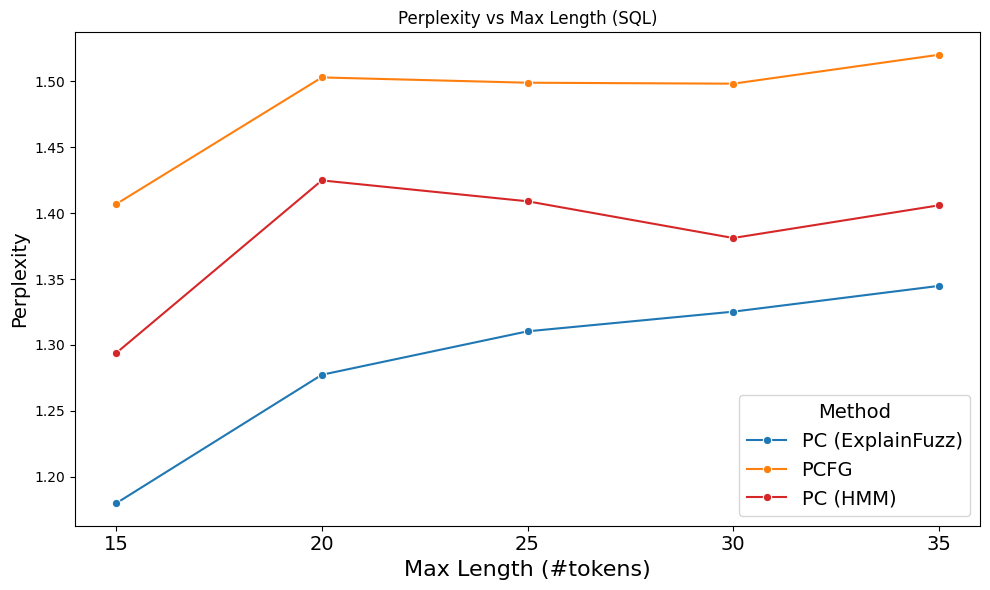

In [5]:
domain="SQL"

compare_results_model(
    domain,
    file_path_results_PC,
    file_path_results_PCFC,
    file_path_results_LLM,
    file_path_results_Seeds,
    file_path_results_HMM
)

In [6]:
domains = ["SQL", "JANUS", "REDIS", "B", "CSV", "HTML", "JSON"]
df_filtered = comparison_perplexity_domains_with_HMM_only_realistic_data(domains,
        file_path_results_PC,
        file_path_results_PCFC,
        file_path_results_LLM,
        file_path_results_HMM,
        file_path_results_Seeds
    )
    
latex = df_filtered_to_latex_table(df_filtered,caption= "Perplexity per Domain", label="tab:perplexity_domain_comparison")
print(latex)

/tmp/ipykernel_119564/3219405258.py:130: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pivot = pivot.applymap(lambda x: f"{x:.2f}")


\begin{table}
\caption{Perplexity per Domain}
\label{tab:perplexity_domain_comparison}
\begin{tabular}{lccccc}
\toprule
method & max_length & LLM & PCFG & PC (HMM) & PC (ExplainFuzz) \\
domain &  &  &  &  &  \\
\midrule
B & 40 & 7.19 & 2.43 & 1.53 & \textbf{1.51} \\
CSV & 45 & 2.83 & 1.46 & 1.20 & \textbf{1.15} \\
HTML & 50 & 9.03 & 1.31 & 1.26 & \textbf{1.20} \\
JANUS & 30 & 15.05 & 2.53 & \textbf{1.56} & 1.61 \\
JSON & 50 & 6.37 & 1.88 & 1.37 & \textbf{1.32} \\
REDIS & 15 & 2744.53 & 2.13 & \textbf{2.09} & 2.19 \\
SQL & 35 & 280.93 & 1.52 & 1.41 & \textbf{1.34} \\
\bottomrule
\end{tabular}
\end{table}



## Scalability evaluation


In [7]:
# IMPORT
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math


In [8]:

def compare_grammar_complexity(domains, results_grammars_file):
    # Load and merge data
    data = []
    for domain in domains:
        df = get_df_domain(domain, results_grammars_file)
        df["nb_recursive_rules"] = df["percent_recursive"] * df["num_productions"]
        data.append(df)

    df_all = pd.concat(data, ignore_index=True)

    # Select and log-transform relevant metrics
    metrics = [
        "num_rules",
        "num_productions",
        "num_terminals",
        "avg_arity",
        "nb_recursive_rules",
    ]
    df_plot = df_all[["domain"] + metrics].copy()
    for m in metrics:
        df_plot[m] = df_plot[m].apply(lambda x: math.log1p(x))  # log(1+x) to handle 0

    # Melt for seaborn plotting
    df_melted = pd.melt(
        df_plot, id_vars=["domain"], var_name="Metric", value_name="Value"
    )

    # Plot
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_melted, x="Value", y="domain", hue="Metric")
    plt.xlabel("Log-Scaled Value")
    plt.ylabel("Domain")
    plt.title("Grammar Complexity Comparison Across Domains")
    plt.tight_layout()
    plt.show()



In [9]:
def plot_seed_lengths(domains, results_seeds_file):
    # Flatten into a DataFrame
    data = []
    for domain in domains:
        df = get_df_domain(domain, results_seeds_file)
        data.append(df)

    df_all = pd.concat(data, ignore_index=True)

    df_plot = df_all[["domain", "avg_sequence_length"]]
    df_plot = df_plot.rename(
        columns={
            "domain": "Domain",
            "avg_sequence_length": "Avg Length",
        }
    )
    df_melted = df_plot.melt(id_vars="Domain", var_name="Metric", value_name="Length")
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_melted, x="Domain", y="Length", hue="Metric", palette="Set2")
    plt.yscale("log")
    plt.title("Seed Sequence Lengths per Domain (Log Scale)")
    plt.ylabel("Sequence Length (log scale - #tokens)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.legend(title="Metric")
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.show()

In [10]:
def compare_circuit_size(domains, results_PC_file):
    data = []
    for domain in domains:
        df = get_df_domain(domain, results_PC_file)
        df = df[df["mode"] == "no-generate"]
        data.append(df)

    df_all = pd.concat(data, ignore_index=True)

    palette = sns.color_palette(n_colors=len(df_all["domain"].unique()))
    domain_colors = dict(zip(df_all["domain"].unique(), palette))

    sns.lineplot(
        data=df_all,
        x="max_length",
        y="circuit_size",
        hue="domain",
        palette=domain_colors,
    )

    # Add stars at average seed length with domain-specific color
    # for domain in df_all["domain"].unique():
    #     df_seed = get_df_domain(domain, results_seeds_file)
    #     x_star = int(df_seed["avg_sequence_length"].iloc[0]) // 5 * 5
    #     subset = df_all[(df_all["domain"] == domain) & (df_all["max_length"] == x_star)]

    #     if not subset.empty:
    #         y_star = subset["circuit_size"].values[0]
    #         plt.scatter(
    #             x_star,
    #             y_star,
    #             marker="*",
    #             s=150,
    #             color=domain_colors[domain],
    #             label="_nolegend_",
    #         )

    # plt.scatter([], [], marker="*", s=150, color="black", label="Avg seed length")
    plt.title("Circuit Size vs Max Length")
    plt.xlabel("Max length (#tokens)")
    plt.ylabel("Circuit Size (#nodes)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [11]:
def compare_train_time(domains, results_PC_file, results_seeds_file):
    data = []
    data_seed = []
    for domain in domains:
        df = get_df_domain(domain, results_PC_file)
        df = df[df["mode"] == "no-generate"]
        data.append(df)

    df_all = pd.concat(data, ignore_index=True)

    palette = sns.color_palette(n_colors=len(df_all["domain"].unique()))
    domain_colors = dict(zip(df_all["domain"].unique(), palette))

    sns.lineplot(data=df_all, x="max_length", y="train_time", hue="domain")
    for domain in df_all["domain"].unique():
        df_seed = get_df_domain(domain, results_seeds_file)
        x_star = int(df_seed["avg_sequence_length"].iloc[0]) // 5 * 5
        subset = df_all[(df_all["domain"] == domain) & (df_all["max_length"] == x_star)]

        if not subset.empty:
            y_star = subset["train_time"].values[0]
            plt.scatter(
                x_star,
                y_star,
                marker="*",
                s=150,
                color=domain_colors[domain],
                label="_nolegend_",
            )

    plt.scatter([], [], marker="*", s=150, color="black", label="Avg seed length")

    plt.title(f"Training time VS Max length")
    plt.xlabel("Max length (#tokens)")
    plt.ylabel("Training time (seconds)")
    plt.legend()
    plt.grid(True)
    plt.show()

In [12]:
def compare_compilation_time(domains, results_PC_file, results_seeds_file):
    data = []
    for domain in domains:
        df = get_df_domain(domain, results_PC_file)
        df = df[df["mode"] == "no-generate"]
        data.append(df)

    df_all = pd.concat(data, ignore_index=True)

    palette = sns.color_palette(n_colors=len(df_all["domain"].unique()))
    domain_colors = dict(zip(df_all["domain"].unique(), palette))
    sns.lineplot(data=df_all, x="max_length", y="time_building_circuit", hue="domain")
    # for domain in df_all["domain"].unique():
    #     df_seed = get_df_domain(domain, results_seeds_file)
    #     x_star = int(df_seed["avg_sequence_length"].iloc[0]) // 5 * 5
    #     subset = df_all[(df_all["domain"] == domain) & (df_all["max_length"] == x_star)]

    #     if not subset.empty:
    #         y_star = subset["time_building_circuit"].values[0]
    #         plt.scatter(
    #             x_star,
    #             y_star,
    #             marker="*",
    #             s=150,
    #             color=domain_colors[domain],
    #             label="_nolegend_",
    #         )
    #     elif x_star <= 200:
    #         plt.scatter(
    #             x_star,
    #             0,
    #             marker="*",
    #             s=150,
    #             color=domain_colors[domain],
    #             label="_nolegend_",
    #         )

    # plt.scatter([], [], marker="*", s=150, color="black", label="Avg seed length")

    plt.title(f"Compilation Time VS Max length")
    plt.xlabel("Max length (#tokens)")
    # plt.yscale("log")
    plt.ylabel("Compilation time (seconds)")
    plt.legend()
    plt.grid(True)
    plt.show()

### Show results


In [13]:
file_path_results_PC = "data/results/PC/eval_PC_model.json"
file_path_results_PCFC = "data/results/PCFG/eval_PCFG.json"
file_path_results_LLM = "data/results/LLM/eval_llm.json"
file_path_results_Seeds = "data/results/SEEDS/eval_seeds.json"
file_path_results_HMM = "data/results/PC-HMM/eval_PC_HMM.json"
file_path_results_grammars = "data/results/grammars/results_grammars.json"

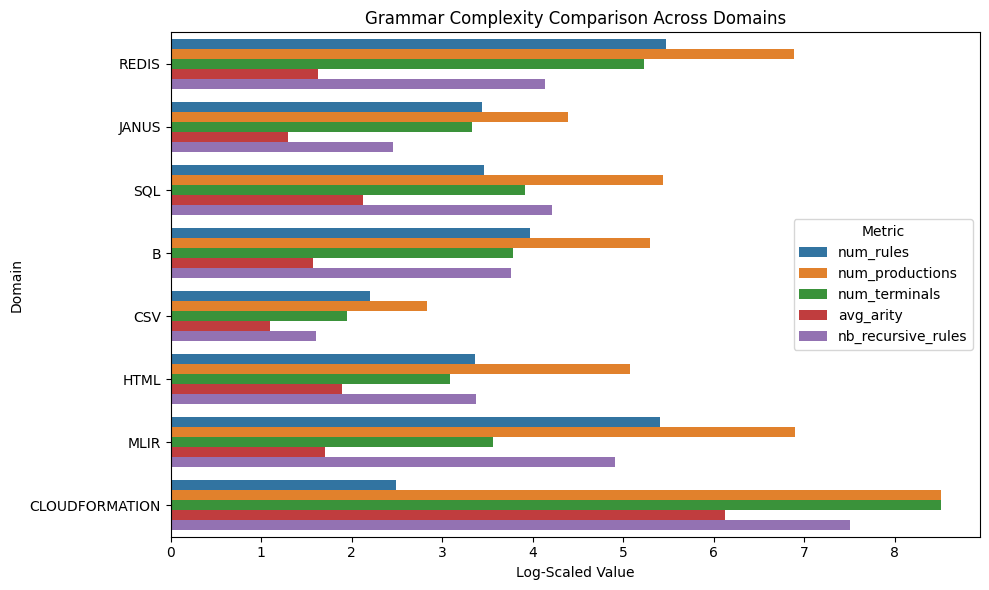

In [14]:
domains = ["REDIS", "JANUS", "SQL", "B", "CSV", "HTML", "MLIR", "CLOUDFORMATION"]
compare_grammar_complexity(
    domains,
   file_path_results_grammars,
)

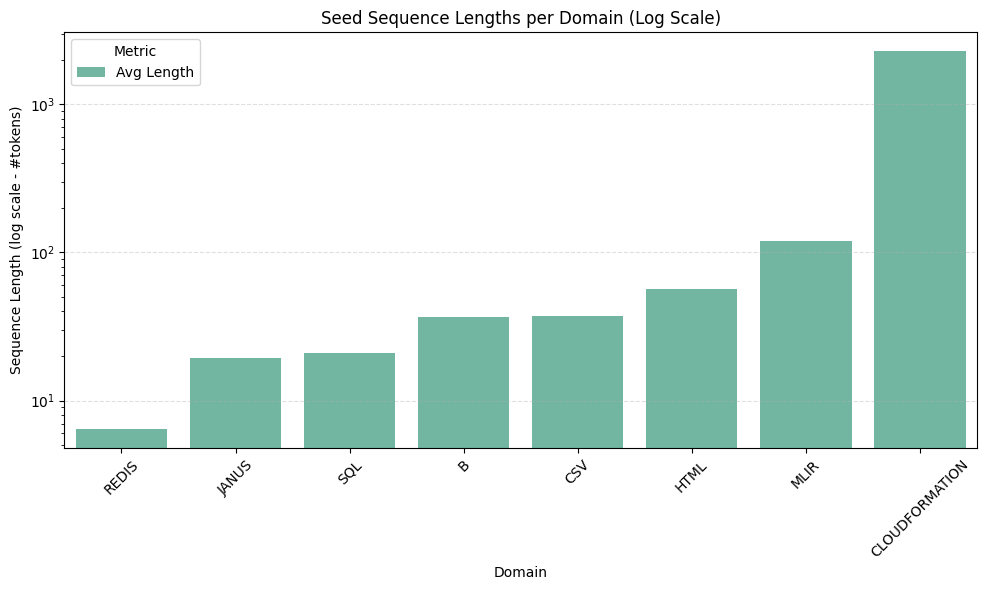

In [15]:
plot_seed_lengths(domains, file_path_results_Seeds)

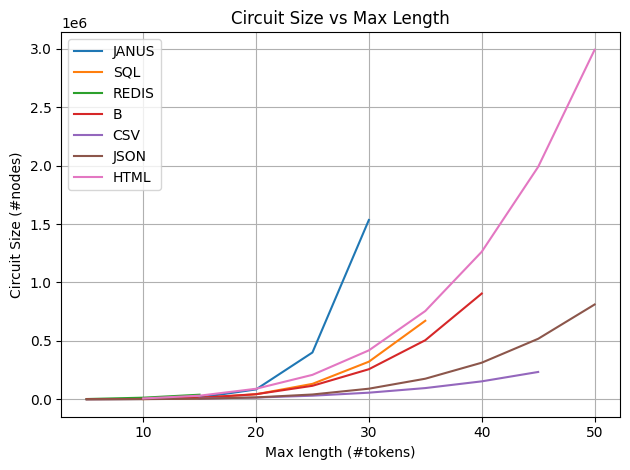

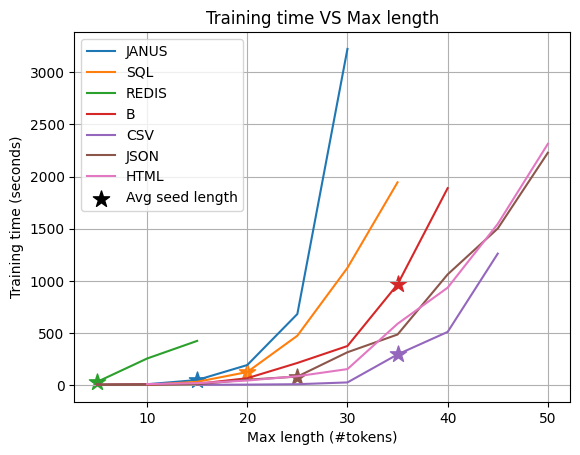

In [16]:
easy_domains = ["JANUS", "SQL", "REDIS", "B", "CSV", "JSON", "HTML"]
compare_circuit_size(easy_domains, file_path_results_PC)
compare_train_time(
        easy_domains,
        file_path_results_PC,
        file_path_results_Seeds,
    )

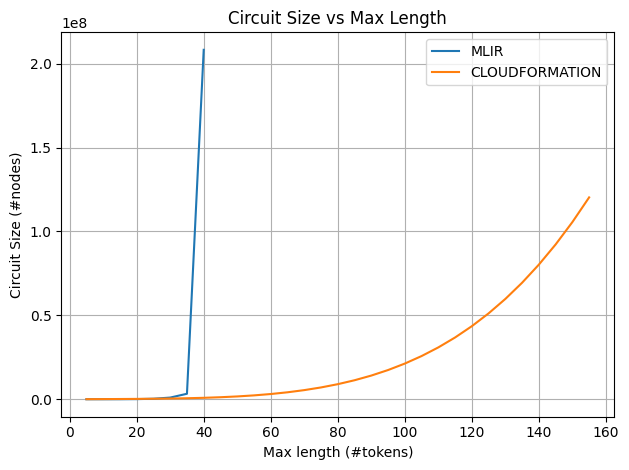

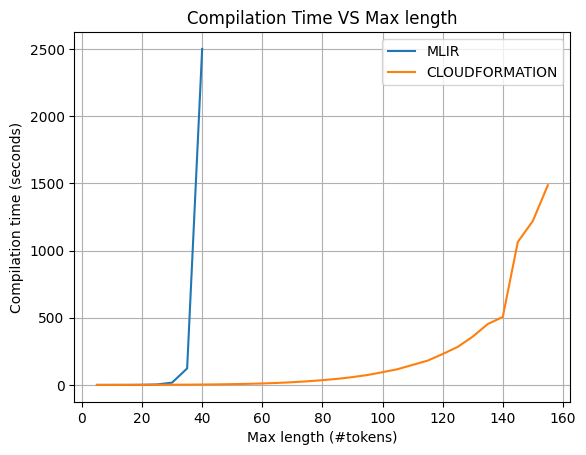

In [17]:
hard_domains = ["MLIR", "CLOUDFORMATION"]
compare_circuit_size(hard_domains, file_path_results_PC)
compare_compilation_time(
        hard_domains,
        file_path_results_PC,
        file_path_results_Seeds,
    )

## Inference evaluation


In [18]:
# IMPORT 
from collections import defaultdict

### Helper functions


In [19]:
def analyze_results(file):
    # Load your JSON from a file
    with open(file, "r") as f:
        data = json.load(f)

    # Structure to accumulate model and ground-truth probabilities
    stats = defaultdict(lambda: {"gt": [], "mae": []})

    for domain, examples in data.items():
        for example_group in examples:
            for entry in example_group:
                query_type = entry.get("query_type")
                model_prob = entry.get("model_prob")
                seed_prob = entry.get("seed_prob")

                if query_type is not None and model_prob is not None and seed_prob is not None:
                    diff = abs(model_prob - seed_prob)
                    stats[(domain, query_type)]["gt"].append(seed_prob)
                    stats[(domain, query_type)]["mae"].append(diff)

    # Build LaTeX table as a string
    latex = []
    latex.append("\\begin{tabular}{llrr}")
    latex.append("\\toprule")
    latex.append("\\textbf{Domain} & \\textbf{Query Type} & \\textbf{Mean GT} & \\textbf{MAE} \\\\")
    latex.append("\\midrule")

    for (domain, query_type), values in sorted(stats.items()):
        mean_gt = sum(values["gt"]) / len(values["gt"]) if values["gt"] else 0.0
        mae = sum(values["mae"]) / len(values["mae"]) if values["mae"] else 0.0
        latex.append(f"{domain} & {query_type} & {mean_gt:.4f} & {mae:.4f} \\\\")

    latex.append("\\bottomrule")
    latex.append("\\end{tabular}")

    # Print instead of save
    print("\n".join(latex))



In [20]:
def generate_table_latex_distribution_seeds(input_file):
    with open(input_file, "r") as f:
        data = json.load(f)
    # Get all literals (row labels)
    literals = list(next(iter(data.values())).keys())
    domains = list(data.keys())

    # Start LaTeX table
    latex = "\\begin{tabular}{l" + "c" * len(domains) + "}\n"
    latex += "Literal & " + " & ".join(domains) + " \\\\\n"
    latex += "\\hline\n"

    # Fill table rows
    for literal in literals:
        row = [f'P("{literal}")']
        for domain in domains:
            value = round(data[domain][literal], 2)
            row.append(f"\\heatcolor{{{value:.2f}}}")
        latex += " & ".join(row) + " \\\\\n"

    latex += "\\end{tabular}"
    print(latex)

### Showing the results


In [21]:
file_path_results_inference_PC =  "data/results/PC/eval_PC_inference.json"
analyze_results(file_path_results_inference_PC)

\begin{tabular}{llrr}
\toprule
\textbf{Domain} & \textbf{Query Type} & \textbf{Mean GT} & \textbf{MAE} \\
\midrule
B & COND1 & 0.5986 & 0.0053 \\
B & EVI & 0.1384 & 0.0647 \\
B & MAR1 & 0.5888 & 0.0038 \\
JANUS & COND1 & 0.7622 & 0.0370 \\
JANUS & EVI & 0.1967 & 0.0991 \\
JANUS & MAR1 & 0.7330 & 0.0399 \\
REDIS & COND1 & 0.6157 & 0.0191 \\
REDIS & EVI & 0.0506 & 0.0288 \\
REDIS & MAR1 & 0.3325 & 0.0213 \\
SQL & COND1 & 0.5172 & 0.0056 \\
SQL & EVI & 0.0762 & 0.0332 \\
SQL & MAR1 & 0.5215 & 0.0237 \\
\bottomrule
\end{tabular}


In [22]:

file_path_results_mar1_seeds_xml = "data/results/SEEDS/eval_mar1_domains_XML.json"
generate_table_latex_distribution_seeds(file_path_results_mar1_seeds_xml)

\begin{tabular}{lcccc}
Literal & XML1 & XML2 & XML3 & XML4 \\
\hline
P("Name") & \heatcolor{1.00} & \heatcolor{1.00} & \heatcolor{1.00} & \heatcolor{1.00} \\
P("CDATA") & \heatcolor{0.00} & \heatcolor{0.33} & \heatcolor{0.01} & \heatcolor{0.17} \\
P("COMMENT") & \heatcolor{0.00} & \heatcolor{0.01} & \heatcolor{0.95} & \heatcolor{0.17} \\
P("EntityRef") & \heatcolor{0.00} & \heatcolor{0.00} & \heatcolor{0.00} & \heatcolor{0.20} \\
P("nested structure") & \heatcolor{0.02} & \heatcolor{0.96} & \heatcolor{0.35} & \heatcolor{0.47} \\
\end{tabular}


In [23]:
file_path_results_mar1_seeds_sql ="data/results/SEEDS/eval_mar1_domains_SQL.json"
generate_table_latex_distribution_seeds(file_path_results_mar1_seeds_sql)

\begin{tabular}{lcccc}
Literal & SQL1A & SQL2A & SQL3A & SQL4A \\
\hline
P("SELECT") & \heatcolor{1.00} & \heatcolor{1.00} & \heatcolor{1.00} & \heatcolor{1.00} \\
P("FROM") & \heatcolor{1.00} & \heatcolor{1.00} & \heatcolor{1.00} & \heatcolor{1.00} \\
P("WHERE") & \heatcolor{0.98} & \heatcolor{0.53} & \heatcolor{0.51} & \heatcolor{0.44} \\
P("JOIN") & \heatcolor{0.00} & \heatcolor{0.13} & \heatcolor{0.21} & \heatcolor{0.18} \\
P("GROUP") & \heatcolor{0.01} & \heatcolor{0.11} & \heatcolor{0.20} & \heatcolor{0.26} \\
P("ORDER") & \heatcolor{0.98} & \heatcolor{0.39} & \heatcolor{0.12} & \heatcolor{0.30} \\
P("HAVING") & \heatcolor{0.01} & \heatcolor{0.06} & \heatcolor{0.01} & \heatcolor{0.12} \\
P("UNION") & \heatcolor{0.00} & \heatcolor{0.04} & \heatcolor{0.00} & \heatcolor{0.13} \\
P("SELECT|SELECT") & \heatcolor{0.00} & \heatcolor{0.07} & \heatcolor{0.12} & \heatcolor{0.15} \\
\end{tabular}


## Multi-bug evaluation


In [24]:
## IMPORT
from bug_specs import BUG_SPECS_XML,BUG_SPECS_SQL
import json
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.colorbar import ColorbarBase
from mpl_toolkits.axes_grid1 import make_axes_locatable

### Functions to aggregate the results


In [25]:
def aggregate_results_per_seed(seed_results, keys):
    """Aggregate ExplainFuzz runs for one seed set.
    
    Handles both scalar keys and per-bug dictionary keys.
    """
    agg = {}
    for key in keys:
        # Check if the first run[key] is a dict (per-bug metric)
        if isinstance(seed_results[0][key], dict):
            # Collect all bug IDs
            bug_ids = set()
            for seed_res in seed_results:
                for bug_trig in seed_res[key].keys():
                    bug_ids.add(bug_trig)
            agg[key] = {}
            for bug in bug_ids:
                vals = [run.get(key,{}).get(bug, 0) for run in seed_results]
                agg[key][bug] = {
                    "mean": np.mean(vals),
                    "std": np.std(vals)
                }
        elif isinstance(seed_results[0][key], str):
            # String metric, keep the first one
            agg[key] = seed_results[0][key]
        else:
            # Scalar metric
            # print([run for run in seed_results])
            vals = [run[key] for run in seed_results]
            agg[key] = {
                "mean": np.mean(vals),
                "std": np.std(vals)
            }
    return agg

def generate_final_summary_multi_bug_evaluation(keys,file_path_summary,res_file_paths:dict):
    final_summary={}
    for domain,file_path in res_file_paths.items():
        with open(file_path, "r") as f:
            results = json.load(f)
        res_grammarinator = aggregate_results_per_seed(results["Grammarinator"],keys)
        res_explainfuzz = aggregate_results_per_seed(results["ExplainFuzz"],keys)
        final_summary[domain]={"Grammarinator":res_grammarinator,"ExplainFuzz":res_explainfuzz}

    with open(file_path_summary, "w") as f:
        json.dump(final_summary, f, indent=4, default=str)

In [26]:
def update_summary_with_conditioning_results(conditioning_results,keys,summary_domain):
    for cond_res in conditioning_results:
        aggregated_cond_res = aggregate_results_per_seed(cond_res,keys+["conditioning_token"])
        lit_condition = aggregated_cond_res.get("conditioning_token",None)
        method_key = f"ExplainFuzz + {lit_condition}"
        summary_domain[method_key] = aggregated_cond_res
    return summary_domain

def generate_final_summary_conditioning_evaluation(keys:list[str],file_path_summary:str,res_file_paths_sql:dict):
    final_summary={}
    for domain,file_path in res_file_paths_sql.items():
        with open(file_path, "r") as f:
            results = json.load(f)
        res_grammarinator = aggregate_results_per_seed(results["Grammarinator"],keys)
        res_explainfuzz = aggregate_results_per_seed(results["ExplainFuzz"],keys)
        summary_domain = {"Grammarinator":res_grammarinator,"ExplainFuzz":res_explainfuzz}
        summary_domain = update_summary_with_conditioning_results(results["ExplainFuzz + conditioning"],keys,summary_domain)

        final_summary[domain]=summary_domain

    with open(file_path_summary, "w") as f:
        json.dump(final_summary, f, indent=4, default=str)

### Generating the summary files for SQL


In [27]:
domains_sql = ["SQL1A","SQL2A","SQL3A","SQL4A"]

In [28]:
res_file_paths_sql ={}
for domain in domains_sql:
    file_path = f"data/results/multi_bug_rate/SQL/eval_multi_bug_{domain}.json"
    res_file_paths_sql[domain] = file_path

In [29]:
keys = ["executable_rate", "nb_distinct_bugs_triggered", "coverage",
            "total_triggers", "total_distinct_queries", 
            "avg_inputs_per_bug", "avg_distinct_per_bug","explicit_sensitive"]
file_path_summary_sql = "data/results/multi_bug_rate/SQL/summary_results_multi_bug.json"
generate_final_summary_multi_bug_evaluation(keys,file_path_summary_sql,res_file_paths_sql)

In [30]:
file_path_summary_per_bug_sql = "data/results/multi_bug_rate/SQL/per_bug_results_multi_bug.json"
keys_per_bug=["per_bug_counts_distinct","per_bug_explicit_sensitive"]
generate_final_summary_multi_bug_evaluation(keys_per_bug,file_path_summary_per_bug_sql,res_file_paths_sql)

In [31]:
res_cond_file_paths_sql ={}
for domain in domains_sql:
    file_path = f"data/results/multi_bug_rate/SQL/eval_cond_{domain}.json"
    res_cond_file_paths_sql[domain] = file_path

keys = ["executable_rate", "nb_distinct_bugs_triggered", "coverage",
            "total_triggers", "total_distinct_queries", 
            "avg_inputs_per_bug", "avg_distinct_per_bug","explicit_sensitive","per_bug_counts_distinct"]
file_path_summary_conditioning_sql = "data/results/multi_bug_rate/SQL/summary_results_multi_bug_with_conditioning.json"
generate_final_summary_conditioning_evaluation(keys, file_path_summary_conditioning_sql,res_cond_file_paths_sql)


### Generating the summary files for XML


In [32]:
domains_xml = ["XML1","XML2","XML3","XML4"]

In [33]:
res_file_paths_xml ={}
for domain in domains_xml:
    file_path = f"data/results/multi_bug_rate/XML/eval_multi_bug_{domain}.json"
    res_file_paths_xml[domain] = file_path

In [34]:
keys = ["executable_rate", "nb_distinct_bugs_triggered", "coverage",
            "total_triggers", "total_distinct_queries", 
            "avg_inputs_per_bug", "avg_distinct_per_bug"]
file_path_summary_xml = "data/results/multi_bug_rate/XML/summary_results_multi_bug.json"
generate_final_summary_multi_bug_evaluation(keys,file_path_summary_xml,res_file_paths_xml)

In [35]:
file_path_summary_per_bug_xml = "data/results/multi_bug_rate/XML/per_bug_results_multi_bug.json"
keys_per_bug=["per_bug_counts_distinct"]
generate_final_summary_multi_bug_evaluation(keys_per_bug,file_path_summary_per_bug_xml,res_file_paths_xml)

In [36]:
res_cond_file_paths_xml ={}
for domain in domains_xml:
    file_path = f"data/results/multi_bug_rate/XML/eval_cond_{domain}.json"
    res_cond_file_paths_xml[domain] = file_path
keys = ["executable_rate", "nb_distinct_bugs_triggered", "coverage",
        "total_triggers", "total_distinct_queries", 
        "avg_inputs_per_bug", "avg_distinct_per_bug","per_bug_counts_distinct"]
file_path_summary_conditioning_xml = "data/results/multi_bug_rate/XML/summary_results_multi_bug_with_conditioning.json"
generate_final_summary_conditioning_evaluation(keys, file_path_summary_conditioning_xml,res_cond_file_paths_xml)


### Functions to plot and generate latex tables


In [37]:
def summarize_conditioning_results(results_json_path: str, bug_specs: dict, domain: str):
    """
    Compute conditioning metrics and produce a summary table for a given domain (SQL or XML).
    
    Args:
        results_json_path: path to the JSON file containing conditioning results.
        bug_specs: dict containing the bug specifications (BUG_SPECS_XML or BUG_SPECS_SQL).
        domain: either "XML" or "SQL".
    
    Returns:
        A pandas DataFrame summarizing all metrics.
    """
    # Load results
    with open(results_json_path, "r") as f:
        data = json.load(f)
    domain_data = data[domain]
    
    # Identify base models
    base_ef = domain_data["ExplainFuzz"]["per_bug_counts_distinct"]
    base_gram = domain_data["Grammarinator"]["per_bug_counts_distinct"]
    
    # Get all conditioned models (keys starting with "ExplainFuzz +")
    cond_models = [m for m in domain_data.keys() if m.startswith("ExplainFuzz +")]
    
    summary_rows = []
    
    all_distinct_bugs = set()
    new_bugs_ef_id = set()
    new_bugs_gram_id = set()
    for model in cond_models:
        cond_token = domain_data[model].get("conditioning_token")
        cond_bugs = []
        
        # find related bugs
        if "XML" in domain:
            # special case for 5xEntityRef
            cond_bugs = [
                b for b, spec in bug_specs.items()
                if spec.get("cond_token") == cond_token
                or (cond_token == "5xEntityRef" and spec.get("cond_token") == "EntityRef")
            ]
        elif "SQL" in domain:
            cond_bugs = [
                b for b, spec in bug_specs.items()
                if cond_token in spec.get("required", [])
            ]
        
        if not cond_bugs:
            continue
        
        related_total = len(cond_bugs)
        related_expected = 0
        new_bugs_ef = 0
        new_bugs_gram = 0
        ratios_ef, ratios_gram = [], []
        
        for bug in cond_bugs:
            cond_val = domain_data[model]["per_bug_counts_distinct"].get(bug, {}).get("mean", 0)
            ef_val = base_ef.get(bug, {}).get("mean", 0)
            gram_val = base_gram.get(bug, {}).get("mean", 0)
            
            # Compute diversity ratios
            ratio_ef = cond_val - ef_val
            ratio_gram = cond_val - gram_val
            ratios_ef.append(ratio_ef)
            ratios_gram.append(ratio_gram)
            
            # "Expected" if conditioned version performs > unconditioned
            if cond_val > ef_val:
                related_expected += 1
            
            # New bug discovery
            if cond_val > 0 and ef_val == 0:
                new_bugs_ef += 1
                new_bugs_ef_id.add(bug)
            if cond_val > 0 and gram_val == 0:
                new_bugs_gram += 1
                new_bugs_gram_id.add(bug)
        
        # Aggregate metrics
        alignment_ef = f"{related_expected}/{related_total}"
        alignment_gram = f"{related_expected}/{related_total}"  # same count of related bugs
        avg_ratio_ef = round(sum(ratios_ef) / len(ratios_ef), 2)
        avg_ratio_gram = round(sum(ratios_gram) / len(ratios_gram), 2)
        coverage = round(domain_data[model].get("coverage").get("mean"),1)
        
        summary_rows.append({
            "cond_model": model,
            "bug_coverage":coverage,
            "alignment_vs_EF": alignment_ef,
            "new_bugs_vs_EF": new_bugs_ef,
            "avg_diversity_increase_vs_EF": avg_ratio_ef,
            "alignment_vs_Grammarinator": alignment_gram,
            "new_bugs_vs_Grammarinator": new_bugs_gram,
            "avg_diversity_increase_vs_Grammarinator": avg_ratio_gram,
        })


        bugs_triggered = domain_data[model].get("per_bug_counts_distinct")
        for bug_id in bugs_triggered.keys():
            all_distinct_bugs.add(bug_id)
    
    # Compute global row
    total_related = sum(int(r["alignment_vs_EF"].split("/")[1]) for r in summary_rows)
    total_expected = sum(int(r["alignment_vs_EF"].split("/")[0]) for r in summary_rows)


    total_new_ef = len(new_bugs_ef_id)
    total_new_gram = len(new_bugs_gram_id)


    avg_ratio_ef = round(sum(r["avg_diversity_increase_vs_EF"] for r in summary_rows) / len(summary_rows), 2)
    avg_ratio_gram = round(sum(r["avg_diversity_increase_vs_Grammarinator"] for r in summary_rows) / len(summary_rows), 2)
    
    nb_total_bugs = len(list(bug_specs.keys()))
    global_coverage = round(100* len(all_distinct_bugs)/nb_total_bugs,1)

    summary_rows.append({
        "cond_model": "Global result",
        "bug_coverage": global_coverage,
        "alignment_vs_EF": f"{total_expected}/{total_related}",
        "new_bugs_vs_EF": total_new_ef,
        "avg_diversity_increase_vs_EF": avg_ratio_ef,
        "alignment_vs_Grammarinator": f"{total_expected}/{total_related}",
        "new_bugs_vs_Grammarinator": total_new_gram,
        "avg_diversity_increase_vs_Grammarinator": avg_ratio_gram,
    })
    
    df = pd.DataFrame(summary_rows)
    return df


def generate_conditioning_summary_latex(results_json_path: str, bug_specs: dict, domain: str):
    """
    Generate a LaTeX table summarizing conditioning results for a given domain.

    Expected DataFrame columns:
        ["cond_model", "bug_coverage",
         "alignment_vs_EF", "new_bugs_vs_EF", "avg_diversity_increase_vs_EF",
         "alignment_vs_Grammarinator", "new_bugs_vs_Grammarinator", "avg_diversity_increase_vs_Grammarinator"]
    """
    df = summarize_conditioning_results(results_json_path, bug_specs, domain)

    lines = []
    lines.append("\\begin{tabular}{lcc cc cc}")
    lines.append("\\toprule")
    lines.append("& & & \\multicolumn{2}{c}{vs ExplainFuzz} & \\multicolumn{2}{c}{vs Grammarinator} \\\\")
    lines.append("\\cmidrule(lr){4-5} \\cmidrule(lr){6-7}")
    lines.append("Conditioned Model & Alignment & Bug Coverage & New Bugs & Avg Diversity & New Bugs & Avg Diversity \\\\")
    lines.append("\\midrule")

    # Body rows
    for _, row in df.iterrows():
        if row['cond_model']!="Global result":
            lines.append(
                f"{row['cond_model']:<15} & {row['alignment_vs_EF']} & {row['bug_coverage']}\\% "
                f" & {row['new_bugs_vs_EF']} & +{row['avg_diversity_increase_vs_EF']:.2f} & "
                f"{row['new_bugs_vs_Grammarinator']} & +{row['avg_diversity_increase_vs_Grammarinator']:.2f} \\\\"
            )
        else:
            lines.append("\\midrule")
            lines.append(
                f"\\textbf{{{row['cond_model']:<15}}} & \\textbf{{{row['alignment_vs_EF']}}} & \\textbf{{{row['bug_coverage']}\\%}} &"
                f" \\textbf{{{row['new_bugs_vs_EF']}}} & \\textbf{{+{row['avg_diversity_increase_vs_EF']:.2f}}} & "
                f" \\textbf{{{row['new_bugs_vs_Grammarinator']}}} & \\textbf{{+{row['avg_diversity_increase_vs_Grammarinator']:.2f}}} \\\\"
            )

    lines.append("\\bottomrule")
    lines.append("\\end{tabular}")

    latex_table = "\n".join(lines)
    print(f"✅ Generated LaTeX table for {domain}:\n")
    print(latex_table)
    return latex_table

In [38]:
def _collect_conditioning_results_bug_level_to_dataframe(file_path, domain,bug_specs,desired_order = [("ExplainFuzz", "None")]):
    with open(file_path, "r") as f:
        summary = json.load(f)

    domain_data = summary[domain]
    rows = []
    exec_rate_rows = []

    all_model_conditionings = set()
    all_bug_ids = set(bug_specs.keys())

    for method_name, data in domain_data.items():
        # Extract conditioning token
        if " + " in method_name:
            model = "ExplainFuzz"
            conditioning = method_name.split(" + ")[-1]
        else:
            model = method_name
            conditioning = "None"
        all_model_conditionings.add((model, conditioning))

        exec_rate_data = data.get("executable_rate", {})
        exec_rate = exec_rate_data.get("mean", 0) if isinstance(exec_rate_data, dict) else exec_rate_data
        exec_rate_rows.append({
            "bug_id": "Execution rate",  # This will appear as a header row
            "model": model,
            "conditioning": conditioning,
            "distinct_queries": round(exec_rate,2) # Convert to percentage if in [0,1]
        })

        per_bug = data.get("per_bug_counts_distinct", {})
        if not per_bug:
            # No bugs triggered at all → keep placeholder zeros later
            continue

        # Handle cases where values might be {bug: {"mean": val, "std": ...}}
        per_bug = {b: (v["mean"] if isinstance(v, dict) and "mean" in v else v)
                   for b, v in per_bug.items()}

        for bug, val in per_bug.items():
            if bug not in all_bug_ids:
                continue
            rows.append({
                "bug_id": bug,
                "model": model,
                "conditioning": conditioning,
                "distinct_queries": val
            })


    df = pd.DataFrame(rows+exec_rate_rows)
    if df.empty:
        return pd.DataFrame(columns=pd.MultiIndex.from_tuples(sorted(all_model_conditionings)))

    # Pivot: rows = bugs, columns = model + conditioning
    pivot = df.pivot_table(
        index="bug_id",
        columns=["model", "conditioning"],
        values="distinct_queries",
        fill_value=0,
        aggfunc="mean"
    )

    # ---- Ensure all models and bugs are represented ----
    pivot = pivot.reindex(columns=pd.MultiIndex.from_tuples(sorted(all_model_conditionings)), fill_value=0)
    ordered_bugs = ["Execution rate"] + sorted(all_bug_ids)
    pivot = pivot.reindex(index=ordered_bugs, fill_value=0)

    # ---- Column ordering ----
    
    # others = sorted([m for m in pivot.columns if m not in desired_order])
    pivot = pivot[desired_order]
    return pivot

def plot_bug_level_heatmap_with_exec(file_path, domain,bug_specs,desired_order = [("ExplainFuzz", "None")]):
    """
    Heatmap with 'Execution rate' as first row.
    - Execution rate uses a blue color scale.
    - Other rows use a green-red scale normalized per row.
    - 'Execution rate' index is bold.
    """
    pivot = _collect_conditioning_results_bug_level_to_dataframe(file_path, domain, bug_specs,desired_order)

    # Separate execution rate row if present
    has_exec = "Execution rate" in pivot.index
    if has_exec:
        exec_row = pivot.loc[["Execution rate"]]
        data = pivot.drop(index="Execution rate")
    else:
        exec_row = None
        data = pivot

    
    # Normalize bug rows individually (so each bug's color reflects relative counts)
    ceiled_data = data.map(lambda x: math.ceil(x) if pd.notnull(x) else 0)
    norm_data = ceiled_data.div(data.max(axis=1), axis=0).fillna(0)

    # --- Quantize normalized data based on ceil of original values ---

    # Combine execution rate (0–100%) at the top
    if exec_row is not None: 
        combined = pd.concat([exec_row / 100.0, norm_data]) 
    else: 
        combined = norm_data

    # Prepare annotations
    ann = combined.copy().astype(str)
    if exec_row is not None:
        ann.loc["Execution rate"] = [f"{v:.1f}%" for v in exec_row.loc["Execution rate"]]
    for idx in data.index:
        ann.loc[idx] = data.loc[idx].apply(lambda x: f"{math.ceil(x):d}")

    # Create figure with wider cells to prevent overlap
    n_cols = len(combined.columns)
    fig_width = max(6, n_cols * 1.2)  # 1.2 inches per column for better spacing
    plt.figure(figsize=(fig_width, max(6, len(combined) * 0.4)))

    # Plot main heatmap
    ax = sns.heatmap(
        combined,
        annot=ann,
        fmt="",
        cmap="Blues",
        cbar=False,
        vmin=0,
        vmax=1,
        linewidths=0.5,
        annot_kws={"fontsize": 12}
    )
    
    # Overlay a blue colormap only on the execution rate row (if present)
    if has_exec:
        y0 = 0  # top row in heatmap (matplotlib flips y-axis)
        rdgn_cmap = plt.cm.RdYlGn
        for j, val in enumerate(exec_row.iloc[0] / 100.0):
            color = rdgn_cmap(val)
            ax.add_patch(plt.Rectangle((j, y0), 1, 1, color=color, ec='none', lw=0))
            
        for text in ax.texts:
            text_x, text_y = text.get_position()
            if abs(text.get_position()[1] - (y0 + 0.5)) < 0.1:  # text centered in that row
                col_idx = int(text_x - 0.5)      # get column index corresponding to this text
                val = exec_row.iloc[0, col_idx] / 100.0
                text_color = "white" if val > 0.8 or val < 0.1 else "black"
                text.set_color(text_color)

    yticks = ax.get_yticklabels()
    new_labels = []
    for tick in yticks:
        text = tick.get_text()
        if text == "Execution rate":
            new_labels.append(r"$\bf{Execution\ Rate}$")  # bold label using mathtext
        else:
            new_labels.append(text)
    ax.set_yticklabels(new_labels, rotation=0, fontsize=12)

    new_labels_models= []
    for tick in ax.get_xticklabels():
        text = tick.get_text()
        if "None" in text:
            text = text.replace("-None","")
        new_labels_models.append(text)
    ax.set_xticklabels(new_labels_models, rotation=30, ha='right', fontsize=12)

    # Vertical line separator
    ax.axvline(1, color="black", linewidth=2)
    
    # No axis labels or title
    ax.set_xlabel("")
    ax.set_ylabel("")
    
    plt.tight_layout()
    
    # Save figure
    import os
    output_dir = "data/results/figures"
    os.makedirs(output_dir, exist_ok=True)
    domain_name = domain[:-1] if "SQL" in domain else domain
    filename = f"bug_heatmap_{domain_name}_with_exec.png"
    filepath = os.path.join(output_dir, filename)
    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    print(f"Figure saved to: {filepath}")
    
    plt.show()

In [39]:
def plot_bug_level_heatmap_counts(file_path, seeds, bug_specs,main_domain):
    """
    Plots a heatmap showing per-bug, per-seed counts of distinct triggers
    for each model, plus a 'Global' column showing % of seeds with at least one trigger.
    """
    # --- Step 1: collect counts into a DataFrame ---
    with open(file_path, "r") as f:
        summary = json.load(f)

    bugs = list(bug_specs.keys())
    models = ["Grammarinator", "ExplainFuzz"]
    rows = []
    for bug in bugs:
        row = {"Bug ID": bug}
        global_counts = {model: 0 for model in models}
        for seed in seeds:
            for model in models:
                counts = summary[seed][model].get("per_bug_counts_distinct", {})
                # Take mean if present
                if model in ["Grammarinator", "ExplainFuzz"]:
                    counts = {k: v["mean"] for k, v in counts.items()}

                val = counts.get(bug, 0)
                row[f"{seed} {model}"] = val
                if val > 0:
                    global_counts[model] += 1

        # Compute global % (success = triggered in at least 1 seed)
        for model in models:
            percent = 100 * global_counts[model] / len(seeds)
            row[f"Global {model}"] = percent

        rows.append(row)

    df = pd.DataFrame(rows)
    df = df.set_index("Bug ID")
    df.to_csv('save_df.csv')
    # print(df)
    num_columns = len(df.columns)
    # --- Step 2: normalize per-seed counts for color scale ---
    seed_cols = [col for col in df.columns if not col.startswith("Global")]
    global_cols = [col for col in df.columns if col.startswith("Global")]

    ceiled_data = df.map(lambda x: math.ceil(x) if pd.notnull(x) else 0)
    norm_data = ceiled_data.copy()
    # Normalize per-seed counts row-wise (green-red)
    norm_data[seed_cols] = ceiled_data[seed_cols].div(ceiled_data[seed_cols].max(axis=1), axis=0).fillna(0)
    # Normalize global columns for blue scale
    norm_data[global_cols] = ceiled_data[global_cols]/100.0

    # --- Step 3: prepare annotations ---
    ann = df.copy().astype(str)
    for col in seed_cols:
        ann[col] = df[col].apply(lambda x: f"{math.ceil(x):d}")
    for col in global_cols:
        ann[col] = df[col].apply(lambda x: f"{x:.0f}%")

    # --- Step 4: plot heatmap with adjusted width ---
    fig_width = max(6, num_columns * 0.9)  # 0.9 inches per column
    plt.figure(figsize=(fig_width, max(6, len(df)*0.4)))
    ax = sns.heatmap(
        norm_data,
        annot=ann,
        fmt="",
        cmap="Blues",
        cbar=False,
        linewidths=0.5,
        vmin=0,
        vmax=1,
        annot_kws={"fontsize": 12}
    )
    
    for i, bug in enumerate(df.index):
        for j, col in enumerate(global_cols):
            val = norm_data[global_cols].iloc[i, j]
            rect = plt.Rectangle(
                (len(seed_cols) + j, i), 1, 1, 
                color=plt.cm.RdYlGn(val), ec='none'
            )
            ax.add_patch(rect)
            text_color = "white" if val > 0.5 or val < 0.4 else "black"
            # add annotation on top
            ax.text(
                len(seed_cols) + j + 0.5, i + 0.5, ann.iloc[i][col],
                ha='center', va='center', color=text_color, fontsize=12
            )

    # x-axis labels with vertical lines
    xticks = norm_data.columns
    for x in [2, 4, 6, 8]:  # positions between Gram/EF pairs for each seed
        ax.axvline(x, color="black", linewidth=2)
    
    ax.set_xticks([i+0.5 for i in range(len(xticks))])
    ax.set_xticklabels([col.replace("_", "\_") for col in xticks], rotation=30, ha='right', fontsize=12)
    ax.set_yticklabels(df.index, rotation=0, fontsize=12)

    # No title or axis labels
    ax.set_xlabel("")
    ax.set_ylabel("")
    
    plt.tight_layout()

    # Save figure
    import os
    output_dir = "data/results/figures"
    os.makedirs(output_dir, exist_ok=True)
    filename = f"bug_heatmap_{main_domain}_counts.png"
    filepath = os.path.join(output_dir, filename)
    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    print(f"Figure saved to: {filepath}")
    
    plt.show()

<>:94: SyntaxWarning: invalid escape sequence '\_'
<>:94: SyntaxWarning: invalid escape sequence '\_'
/tmp/ipykernel_119564/1041713963.py:94: SyntaxWarning: invalid escape sequence '\_'
  ax.set_xticklabels([col.replace("_", "\_") for col in xticks], rotation=30, ha='right', fontsize=12)


In [40]:
def generate_table_summary_results_multi_domain(file_path_summary_sql,
                                                 file_path_summary_xml,
                                                 metrics,
                                                 seed_labels_sql,
                                                 seed_labels_xml):
    """
    Generate a combined LaTeX table summarizing results for SQL and XML domains.
    Bold the higher mean between Grammarinator and ExplainFuzz for each metric.
    Add a column with short keywords for seed type, using multirow.
    Wrap metric names to reduce width.
    """

    import json

    # --- Load JSON files ---
    with open(file_path_summary_sql, "r") as f_sql:
        data_sql = json.load(f_sql)
    with open(file_path_summary_xml, "r") as f_xml:
        data_xml = json.load(f_xml)

    # Merge both, keeping domain label
    merged_data = {
        "SQL": data_sql,
        "XML": data_xml
    }

    seed_labels = {
        "SQL": seed_labels_sql,
        "XML": seed_labels_xml
    }

    # --- Generate LaTeX table ---
    latex_lines = []
    col_def = "c c c " + " ".join([">{\\centering\\arraybackslash}p{2cm}" for _ in metrics])
    latex_lines.append(f"\\begin{{tabular}}{{{col_def}}}")
    latex_lines.append("\\toprule")

    # Wrap metric names using parbox to allow line breaks
    header = "\multirow{2}{*}{\\centering\\textbf{Seeds}} & \multirow{2}{*}{\\centering\\textbf{Seeds description}} & \multirow{2}{*}{\\centering\\textbf{Model}} & " + " & ".join([f"\multirow{{2}}{{2.1cm}}{{\\centering\\textbf{{{label}}}}}" for _, label in metrics]) + " \\\\[3ex]"    
    latex_lines.append(header)
    latex_lines.append("\\midrule")

    for j, (domain_name, domain_data) in enumerate(merged_data.items()):
        domain_seed_labels = seed_labels[domain_name]

        for i, (seed_name, systems) in enumerate(domain_data.items()):
            seed_label = seed_name.replace("A", "").replace("SQL", "SQL-").replace("XML", "XML-")
            seed_type = domain_seed_labels.get(seed_label, "")

            gramm = systems.get("Grammarinator", {})
            expl = systems.get("ExplainFuzz", {})

            def get_mean(sys, m):
                if sys not in systems or m not in systems[sys]:
                    return None
                return systems[sys][m]["mean"]

            # --- compute means for bold comparison ---
            gramm_means = {m: get_mean("Grammarinator", m) for m, _ in metrics}
            expl_means = {m: get_mean("ExplainFuzz", m) for m, _ in metrics}

            def fmt(sys_name, m):
                mean = get_mean(sys_name, m)
                if mean is None:
                    return "--"
                g_mean, e_mean = gramm_means[m], expl_means[m]
                if g_mean is None or e_mean is None:
                    bold = False
                else:
                    if abs(g_mean - e_mean) < 1e-9:
                        bold = True
                    elif sys_name == "Grammarinator":
                        bold = g_mean > e_mean
                    else:
                        bold = e_mean > g_mean
                formatted = f"{mean:.1f}"
                return f"\\textbf{{{formatted}}}" if bold else formatted

            row_gramm = " & ".join(fmt("Grammarinator", m) for m, _ in metrics)
            row_expl = " & ".join(fmt("ExplainFuzz", m) for m, _ in metrics)

            latex_lines.append(
                f"\\multirow{{2}}{{*}}{{{seed_label}}} & "
                f"\\multirow{{2}}{{*}}{{{seed_type}}} & "
                f" Grammarinator & "
                f"{row_gramm} \\\\"
            )
            latex_lines.append(f"& & ExplainFuzz & {row_expl} \\\\")

            # Thin line between seeds
            if i < len(domain_data) - 1:
                latex_lines.append("\\midrule")

        # Thick line between domains
        if j != len(merged_data) - 1:
            latex_lines.append("\\specialrule{0.15em}{2pt}{2pt}")

    latex_lines.append("\\bottomrule")
    latex_lines.append("\\end{tabular}")

    latex_table = "\n".join(latex_lines)
    print(latex_table)
    return latex_table

<>:39: SyntaxWarning: invalid escape sequence '\m'
<>:39: SyntaxWarning: invalid escape sequence '\m'
<>:39: SyntaxWarning: invalid escape sequence '\m'
<>:39: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_119564/2623173775.py:39: SyntaxWarning: invalid escape sequence '\m'
  header = "\multirow{2}{*}{\\centering\\textbf{Seeds}} & \multirow{2}{*}{\\centering\\textbf{Seeds description}} & \multirow{2}{*}{\\centering\\textbf{Model}} & " + " & ".join([f"\multirow{{2}}{{2.1cm}}{{\\centering\\textbf{{{label}}}}}" for _, label in metrics]) + " \\\\[3ex]"
/tmp/ipykernel_119564/2623173775.py:39: SyntaxWarning: invalid escape sequence '\m'
  header = "\multirow{2}{*}{\\centering\\textbf{Seeds}} & \multirow{2}{*}{\\centering\\textbf{Seeds description}} & \multirow{2}{*}{\\centering\\textbf{Model}} & " + " & ".join([f"\multirow{{2}}{{2.1cm}}{{\\centering\\textbf{{{label}}}}}" for _, label in metrics]) + " \\\\[3ex]"


In [41]:
def _compute_global_coverage(model,file_path,bug_specs):
    with open(file_path, "r") as f:
        data = json.load(f)

    
    all_distinct_bugs = set()
    for _,domain_data in data.items():
        models = [m for m in domain_data.keys() if model in m]
        for m in models:
            bugs_triggered = domain_data[m].get("per_bug_counts_distinct")
            for bug_id in bugs_triggered.keys():
                all_distinct_bugs.add(bug_id)
    
    nb_total_bug = len(list(bug_specs.keys()))
    bug_coverage = round(100*len(all_distinct_bugs)/nb_total_bug,2)
    return bug_coverage

def _generate_rows_global_cond_summary_one_domain(df,lines,res_file_path,bug_specs):
    for _, row in df.iterrows():
        lines.append(
            f"{row['Domain']} & "
            f"{row['Bug Coverage (Grammarinator)']:.1f}\\% & "
            f"{row['Bug Coverage (ExplainFuzz)']:.1f}\\% & "
            f"{row['Bug Coverage (EF+Cond)']:.1f}\\% & "
            f"+{row['Diversity vs Gram (ExplainFuzz)']:.2f} & "
            f"+{row['Diversity vs Gram (EF+Cond)']:.2f} \\\\"
        )

    # Add mean row
    mean_gram = _compute_global_coverage("Grammarinator",res_file_path,bug_specs)
    mean_ef = _compute_global_coverage("ExplainFuzz",res_file_path,bug_specs)
    mean_cond = _compute_global_coverage("ExplainFuzz +",res_file_path,bug_specs) # conditioning


    mean_div_ef = df["Diversity vs Gram (ExplainFuzz)"].mean()
    mean_div_cond = df["Diversity vs Gram (EF+Cond)"].mean()

    lines.append("\\midrule")
    lines.append(
        f"\\textbf{{Global}} & "
        f"\\textbf{{{mean_gram:.1f}}}\\% &\\textbf{{{mean_ef:.1f}}}\\% & \\textbf{{{mean_cond:.1f}}}\\% & "
        f"\\textbf{{+{mean_div_ef:.2f}}} & \\textbf{{+{mean_div_cond:.2f}}} \\\\"
    )
    return lines

def _get_global_coverage_and_diversity_data(results_json_path, bug_specs):
    """
    Build a summary table across all domains (seeds) with:
      - Bug coverage for Grammarinator, ExplainFuzz, ExplainFuzz + conditioning
      - Avg diversity vs Grammarinator for ExplainFuzz, ExplainFuzz + conditioning

    Args:
        results_json_path: path to the JSON file containing conditioning results
        bug_specs: dict of BUG_SPECS for the corresponding domain

    Returns:
        pandas.DataFrame with columns:
        ["Domain", "Bug Coverage (Grammarinator)", "Bug Coverage (ExplainFuzz)",
         "Bug Coverage (EF+Cond)", "Diversity vs Gram (ExplainFuzz)",
         "Diversity vs Gram (EF+Cond)"]
    """
    with open(results_json_path, "r") as f:
        all_data = json.load(f)

    rows = []

    for domain, domain_data in all_data.items():
        # --- 1️⃣ Compute coverage for Grammarinator
        gram_coverage = round(domain_data["Grammarinator"]["coverage"]["mean"], 1)

        # --- 2️⃣ Compute coverage for ExplainFuzz
        ef_coverage = round(domain_data["ExplainFuzz"]["coverage"]["mean"], 1)

        # --- 3️⃣ Summarize ExplainFuzz + conditioning
        df_cond = summarize_conditioning_results(results_json_path, bug_specs, domain)
        global_row = df_cond[df_cond["cond_model"] == "Global result"].iloc[0]

        ef_cond_coverage = global_row["bug_coverage"]
        diversity_vs_gram_ef_cond = global_row["avg_diversity_increase_vs_Grammarinator"]

        # --- 4️⃣ Compute diversity vs Grammarinator for base EF (union-based)
        base_gram = domain_data["Grammarinator"]["per_bug_counts_distinct"]
        base_ef = domain_data["ExplainFuzz"]["per_bug_counts_distinct"]

        summary_rows = []
        cond_models = [m for m in domain_data.keys() if m.startswith("ExplainFuzz +")]
        for model in cond_models:
            cond_token = domain_data[model].get("conditioning_token")
            cond_bugs = []
            
            # find related bugs
            if "XML" in domain:
                # special case for 5xEntityRef
                cond_bugs = [
                    b for b, spec in bug_specs.items()
                    if spec.get("cond_token") == cond_token
                    or (cond_token == "5xEntityRef" and spec.get("cond_token") == "EntityRef")
                ]
            elif "SQL" in domain:
                cond_bugs = [
                    b for b, spec in bug_specs.items()
                    if cond_token in spec.get("required", [])
                ]
            
            if not cond_bugs:
                continue
            
            ratios_gram = []
            
            for bug in cond_bugs:
                ef_val = base_ef.get(bug, {}).get("mean", 0)
                gram_val = base_gram.get(bug, {}).get("mean", 0)
                
                # Compute diversity ratios
                ratio_gram = ef_val - gram_val
                ratios_gram.append(ratio_gram)
                
            # Aggregate metrics
            avg_ratio_gram = round(sum(ratios_gram) / len(ratios_gram), 2)
            
            summary_rows.append({
                "cond_model": model,
                "avg_diversity_increase_vs_Grammarinator": avg_ratio_gram,
            })

        # Compute global row
        avg_diversity_vs_gram_ef = round(sum(r["avg_diversity_increase_vs_Grammarinator"] for r in summary_rows) / len(summary_rows), 2)
        

        # --- 5️⃣ Append row
        rows.append({
            "Domain": domain,
            "Bug Coverage (Grammarinator)": gram_coverage,
            "Bug Coverage (ExplainFuzz)": ef_coverage,
            "Bug Coverage (EF+Cond)": ef_cond_coverage,
            "Diversity vs Gram (ExplainFuzz)": avg_diversity_vs_gram_ef,
            "Diversity vs Gram (EF+Cond)": diversity_vs_gram_ef_cond,
        })

    return pd.DataFrame(rows)

def dataframe_to_latex_summary(results_json_path_sql, bug_specs_sql,results_json_path_xml, bug_specs_xml) -> str:
    """
    Convert the summary DataFrame (with bug coverage and diversity metrics)
    into a LaTeX table using booktabs formatting.

    Columns expected:
      ["Domain",
       "Bug Coverage (Grammarinator)",
       "Bug Coverage (ExplainFuzz)",
       "Bug Coverage (EF+Cond)",
       "Diversity vs Gram (ExplainFuzz)",
       "Diversity vs Gram (EF+Cond)"]
    """

    lines = []
    lines.append("\\begin{tabular}{l ccc cc}")
    lines.append("\\toprule")
    lines.append(" & \\multicolumn{3}{c}{Bug Coverage (\\%)} & \\multicolumn{2}{c}{Diversity vs Grammarinator} \\\\")
    lines.append("\\cmidrule(lr){2-4} \\cmidrule(lr){5-6}")
    lines.append("Seed & Grammarinator & ExplainFuzz & EF+Cond & ExplainFuzz & EF+Cond \\\\")
    lines.append("\\midrule")

    # Table rows
    df_sql = _get_global_coverage_and_diversity_data(results_json_path_sql, bug_specs_sql)
    lines = _generate_rows_global_cond_summary_one_domain(df_sql,lines,results_json_path_sql, bug_specs_sql)
    lines.append("\\midrule")
    
    df_xml = _get_global_coverage_and_diversity_data(results_json_path_xml, bug_specs_xml)
    lines = _generate_rows_global_cond_summary_one_domain(df_xml,lines,results_json_path_xml, bug_specs_xml)

    lines.append("\\bottomrule")
    lines.append("\\end{tabular}")
    latex = "\n".join(lines)
    print(latex)
    return latex

### Plotting the figures and latex tables


#### Results with conditioning


In [42]:
bug_specs_xml = BUG_SPECS_XML
order_col_xml = [
        (  'ExplainFuzz',        'None'),
        (  'ExplainFuzz',        'Name'),
        (  'ExplainFuzz',       'CDATA'),
        (  'ExplainFuzz',     'COMMENT'),
        (  'ExplainFuzz',   'EntityRef'),
        (  'ExplainFuzz', '5xEntityRef')
        ]

In [43]:
for domain in domains_xml:
    generate_conditioning_summary_latex(file_path_summary_conditioning_xml,bug_specs_xml,domain)


✅ Generated LaTeX table for XML1:

\begin{tabular}{lcc cc cc}
\toprule
& & & \multicolumn{2}{c}{vs ExplainFuzz} & \multicolumn{2}{c}{vs Grammarinator} \\
\cmidrule(lr){4-5} \cmidrule(lr){6-7}
Conditioned Model & Alignment & Bug Coverage & New Bugs & Avg Diversity & New Bugs & Avg Diversity \\
\midrule
ExplainFuzz + Name & 5/6 & 66.7\%  & 0 & +6.56 & 5 & +337.44 \\
ExplainFuzz + COMMENT & 1/1 & 53.3\%  & 1 & +80.67 & 1 & +80.67 \\
ExplainFuzz + CDATA & 2/2 & 73.3\%  & 0 & +353.33 & 2 & +353.83 \\
ExplainFuzz + EntityRef & 0/1 & 63.3\%  & 0 & +0.00 & 0 & +0.00 \\
ExplainFuzz + 5xEntityRef & 1/1 & 90.0\%  & 1 & +307.00 & 1 & +307.00 \\
\midrule
\textbf{Global result  } & \textbf{9/11} & \textbf{100.0\%} & \textbf{2} & \textbf{+149.51} &  \textbf{9} & \textbf{+215.79} \\
\bottomrule
\end{tabular}
✅ Generated LaTeX table for XML2:

\begin{tabular}{lcc cc cc}
\toprule
& & & \multicolumn{2}{c}{vs ExplainFuzz} & \multicolumn{2}{c}{vs Grammarinator} \\
\cmidrule(lr){4-5} \cmidrule(lr){6-7}
Cond

Figure saved to: data/results/figures/bug_heatmap_XML1_with_exec.png


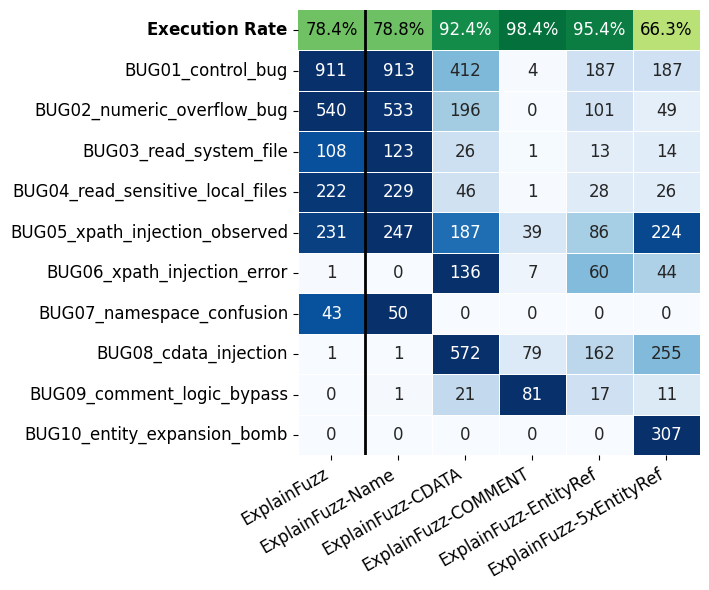

Figure saved to: data/results/figures/bug_heatmap_XML2_with_exec.png


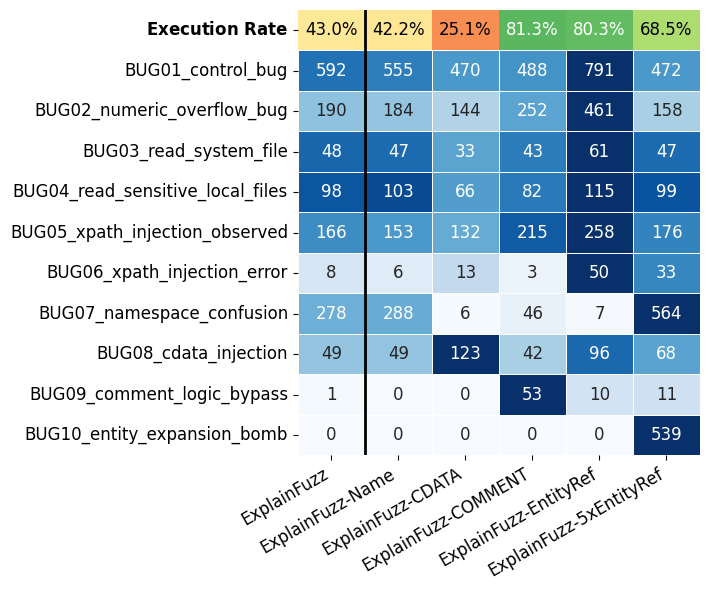

Figure saved to: data/results/figures/bug_heatmap_XML3_with_exec.png


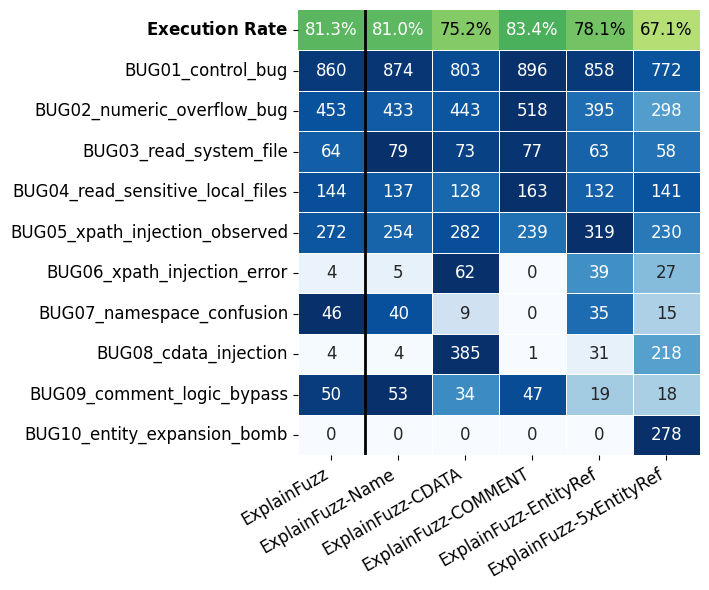

Figure saved to: data/results/figures/bug_heatmap_XML4_with_exec.png


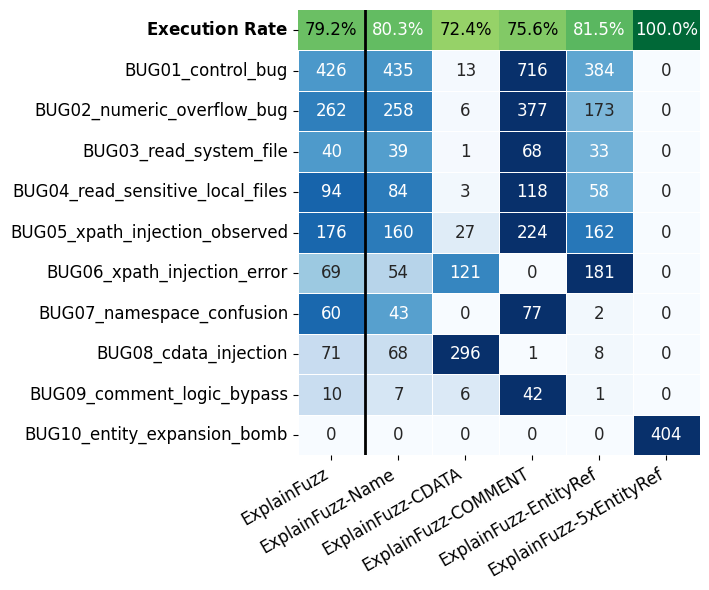

In [44]:
for domain in domains_xml:
    plot_bug_level_heatmap_with_exec(file_path_summary_conditioning_xml, domain,bug_specs_xml,order_col_xml)


Figure saved to: data/results/figures/bug_heatmap_XML1_highlighted.png


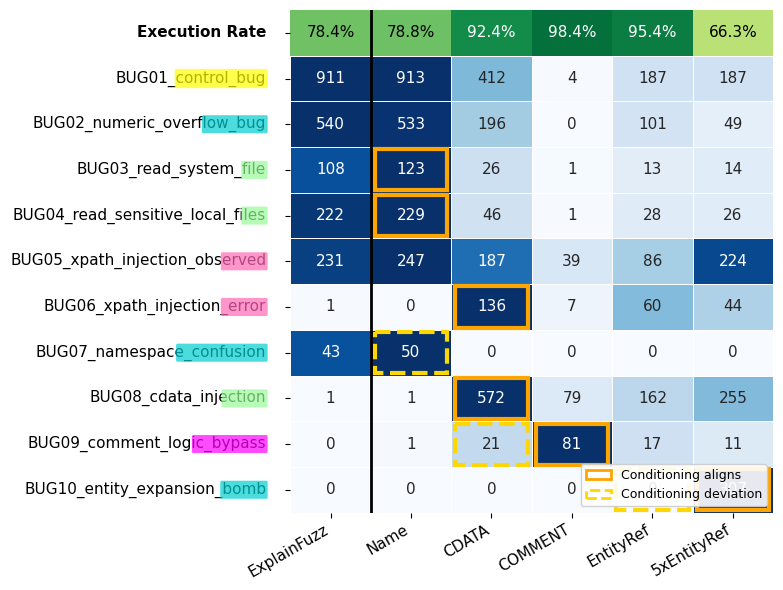

In [45]:
def plot_bug_level_heatmap_xml1_highlighted(file_path, domain, bug_specs, desired_order):
    """
    Specialized heatmap for XML1 with highlighted substrings and cell borders.
    """
    import matplotlib.patches as mpatches
    
    pivot = _collect_conditioning_results_bug_level_to_dataframe(file_path, domain, bug_specs, desired_order)

    has_exec = "Execution rate" in pivot.index
    if has_exec:
        exec_row = pivot.loc[["Execution rate"]]
        data = pivot.drop(index="Execution rate")
    else:
        exec_row = None
        data = pivot

    ceiled_data = data.map(lambda x: math.ceil(x) if pd.notnull(x) else 0)
    norm_data = ceiled_data.div(data.max(axis=1), axis=0).fillna(0)

    if exec_row is not None:
        combined = pd.concat([exec_row / 100.0, norm_data])
    else:
        combined = norm_data

    ann = combined.copy().astype(str)
    if exec_row is not None:
        ann.loc["Execution rate"] = [f"{v:.1f}%" for v in exec_row.loc["Execution rate"]]
    for idx in data.index:
        ann.loc[idx] = data.loc[idx].apply(lambda x: f"{math.ceil(x):d}")

    n_cols = len(combined.columns)
    fig_width = max(8, n_cols * 1.2)
    fig, ax = plt.subplots(figsize=(fig_width, max(6, len(combined) * 0.45)))

    sns.heatmap(
        combined, annot=ann, fmt="", cmap="Blues", cbar=False,
        vmin=0, vmax=1, linewidths=0.5, annot_kws={"fontsize": 11}, ax=ax
    )

    if has_exec:
        y0 = 0
        rdgn_cmap = plt.cm.RdYlGn
        for j, val in enumerate(exec_row.iloc[0] / 100.0):
            ax.add_patch(plt.Rectangle((j, y0), 1, 1, color=rdgn_cmap(val), ec='none', lw=0))
        for text in ax.texts:
            text_x, text_y = text.get_position()
            if abs(text_y - 0.5) < 0.1:
                col_idx = int(text_x - 0.5)
                val = exec_row.iloc[0, col_idx] / 100.0
                text.set_color("white" if val > 0.8 or val < 0.1 else "black")

    # Cell border highlights: (bug_row_idx, col_idx): (color, linestyle, linewidth)
    # Row indices (0=Exec Rate, 1=BUG01, 2=BUG02, ... 10=BUG10)
    # Col indices with Grammarinator: 0=Gram, 1=EF, 2=Name, 3=CDATA, 4=COMMENT, 5=EntityRef, 6=5xEntityRef
    # Col indices without Grammarinator: 0=EF, 1=Name, 2=CDATA, 3=COMMENT, 4=EntityRef, 5=5xEntityRef
    
    # Map based on current columns (no Grammarinator)
    # Name=1, CDATA=2, COMMENT=3, EntityRef=4, 5xEntityRef=5
    cell_highlights = {
        (3, 1): ("orange", "-", 3),    # BUG03 - Name column - aligns
        (4, 1): ("orange", "-", 3),    # BUG04 - Name column - aligns  
        (6, 2): ("orange", "-", 3),    # BUG06 - CDATA column - aligns
        (7, 1): ("gold", "--", 3),     # BUG07 - Name column - deviation
        (8, 2): ("orange", "-", 3),    # BUG08 - CDATA column - aligns
        (9, 3): ("orange", "-", 3),    # BUG09 - COMMENT column - aligns
        (9, 2): ("gold", "--", 3),     # BUG09 - CDATA column - deviation
        (10, 4): ("gold", "--", 3),    # BUG10 - EntityRef column - deviation
        (10, 5): ("orange", "-", 3),   # BUG10 - 5xEntityRef column - aligns
    }

    for (row_idx, col_idx), (color, ls, lw) in cell_highlights.items():
        rect = mpatches.Rectangle(
            (col_idx + 0.05, row_idx + 0.05), 0.9, 0.9,
            linewidth=lw, edgecolor=color, facecolor='none', linestyle=ls
        )
        ax.add_patch(rect)

    # Y-axis labels with highlighted substrings
    highlight_map = {
        "control_bug": "#FFFF00",
        "numeric": "#00CED1", 
        "file": "#98FB98",
        "xpath": "#FF69B4",
        "namespace": "#00CED1",
        "cdata": "#98FB98",
        "comment": "#FF00FF",
        "entity": "#00CED1",
    }

    ax.set_yticklabels([])
    for i, label in enumerate(combined.index):
        y_pos = i + 0.5
        if label == "Execution rate":
            ax.text(-0.05, y_pos, "Execution Rate", ha='right', va='center', fontsize=11,
                   fontweight='bold', transform=ax.get_yaxis_transform())
        else:
            # Find highlight substring
            hl_color = None
            hl_start = hl_end = 0
            for substr, color in highlight_map.items():
                idx = label.lower().find(substr)
                if idx != -1:
                    hl_color = color
                    hl_start = idx
                    hl_end = idx + len(substr)
                    break
            
            if hl_color:
                before = label[:hl_start]
                match = label[hl_start:hl_end]
                after = label[hl_end:]
                
                # Use bbox to highlight the substring
                txt = ax.text(-0.05, y_pos, label, ha='right', va='center', fontsize=11,
                            transform=ax.get_yaxis_transform())
                
                # Add highlighted annotation
                ax.annotate(match, xy=(-0.05, y_pos), xycoords=('axes fraction', 'data'),
                           ha='right', va='center', fontsize=11,
                           bbox=dict(boxstyle='round,pad=0.1', facecolor=hl_color, alpha=0.7, edgecolor='none'),
                           annotation_clip=False, alpha=0)
            else:
                ax.text(-0.05, y_pos, label, ha='right', va='center', fontsize=11,
                       transform=ax.get_yaxis_transform())

    # X-axis labels
    xlabels = [str(c[1]) if c[1] != 'None' else 'ExplainFuzz' for c in combined.columns]
    ax.set_xticklabels(xlabels, rotation=30, ha='right', fontsize=11)

    ax.axvline(1, color="black", linewidth=2)
    ax.set_xlabel("")
    ax.set_ylabel("")

    # Legend
    legend_elements = [
        mpatches.Patch(facecolor='none', edgecolor='orange', linewidth=2, label='Conditioning aligns'),
        mpatches.Patch(facecolor='none', edgecolor='gold', linewidth=2, linestyle='--', label='Conditioning deviation'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=9, framealpha=0.9)

    plt.tight_layout()

    import os
    output_dir = "data/results/figures"
    os.makedirs(output_dir, exist_ok=True)
    filepath = os.path.join(output_dir, "bug_heatmap_XML1_highlighted.png")
    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    print(f"Figure saved to: {filepath}")
    plt.show()

# Generate highlighted XML1 figure
plot_bug_level_heatmap_xml1_highlighted(
    file_path_summary_conditioning_xml, 
    "XML1", 
    bug_specs_xml, 
    order_col_xml
)


In [46]:
bug_specs_sql = BUG_SPECS_SQL
order_col_sql = [
        (  'ExplainFuzz',        'None'),
        (  'ExplainFuzz',        'ORDER'),
        (  'ExplainFuzz',       'WHERE'),
        (  'ExplainFuzz',     'JOIN'),
        (  'ExplainFuzz',   'GROUP'),
        (  'ExplainFuzz', 'UNION')
        ]

In [47]:
for domain in domains_sql:
    generate_conditioning_summary_latex(file_path_summary_conditioning_sql,bug_specs_sql,domain)
  

✅ Generated LaTeX table for SQL1A:

\begin{tabular}{lcc cc cc}
\toprule
& & & \multicolumn{2}{c}{vs ExplainFuzz} & \multicolumn{2}{c}{vs Grammarinator} \\
\cmidrule(lr){4-5} \cmidrule(lr){6-7}
Conditioned Model & Alignment & Bug Coverage & New Bugs & Avg Diversity & New Bugs & Avg Diversity \\
\midrule
ExplainFuzz + ORDER & 0/2 & 17.6\%  & 0 & +-21.33 & 0 & +262.00 \\
ExplainFuzz + WHERE & 0/4 & 17.6\%  & 0 & +-3.42 & 0 & +112.42 \\
ExplainFuzz + JOIN & 2/3 & 27.4\%  & 2 & +7.44 & 2 & +7.44 \\
ExplainFuzz + GROUP & 0/4 & 11.8\%  & 0 & +0.00 & 0 & +0.00 \\
ExplainFuzz + UNION & 0/2 & 0.0\%  & 0 & +0.00 & 0 & +0.00 \\
\midrule
\textbf{Global result  } & \textbf{2/15} & \textbf{33.3\%} & \textbf{2} & \textbf{+-3.46} &  \textbf{2} & \textbf{+76.37} \\
\bottomrule
\end{tabular}
✅ Generated LaTeX table for SQL2A:

\begin{tabular}{lcc cc cc}
\toprule
& & & \multicolumn{2}{c}{vs ExplainFuzz} & \multicolumn{2}{c}{vs Grammarinator} \\
\cmidrule(lr){4-5} \cmidrule(lr){6-7}
Conditioned Model & Ali

Figure saved to: data/results/figures/bug_heatmap_SQL1_with_exec.png


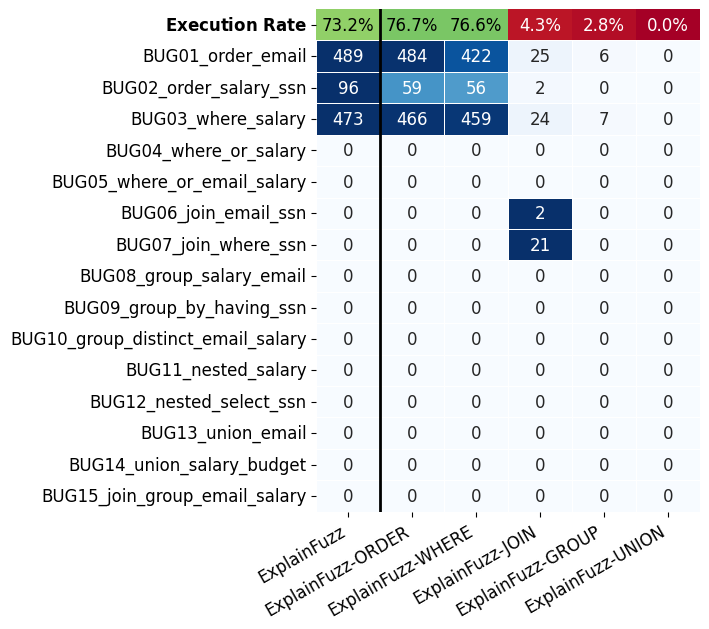

Figure saved to: data/results/figures/bug_heatmap_SQL2_with_exec.png


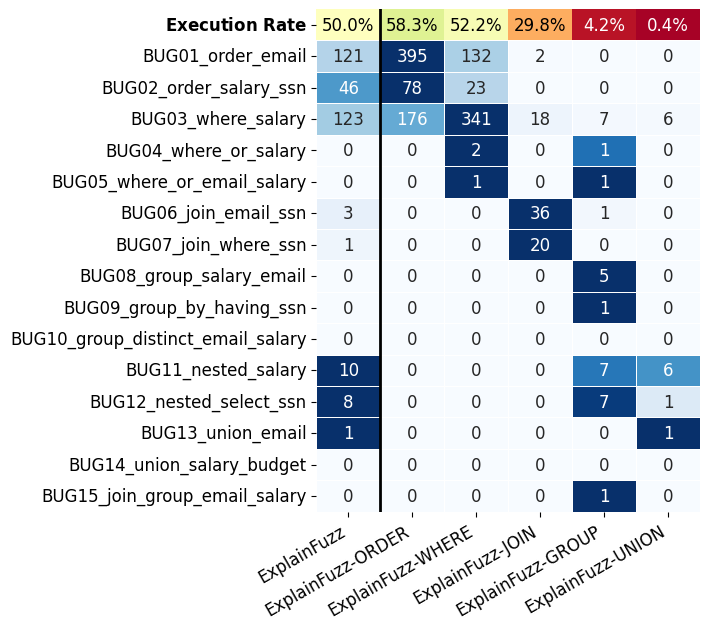

Figure saved to: data/results/figures/bug_heatmap_SQL3_with_exec.png


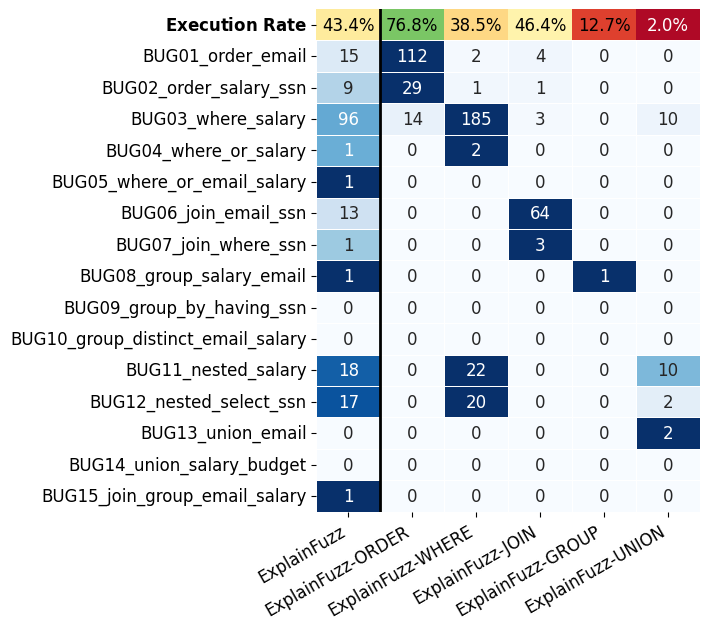

Figure saved to: data/results/figures/bug_heatmap_SQL4_with_exec.png


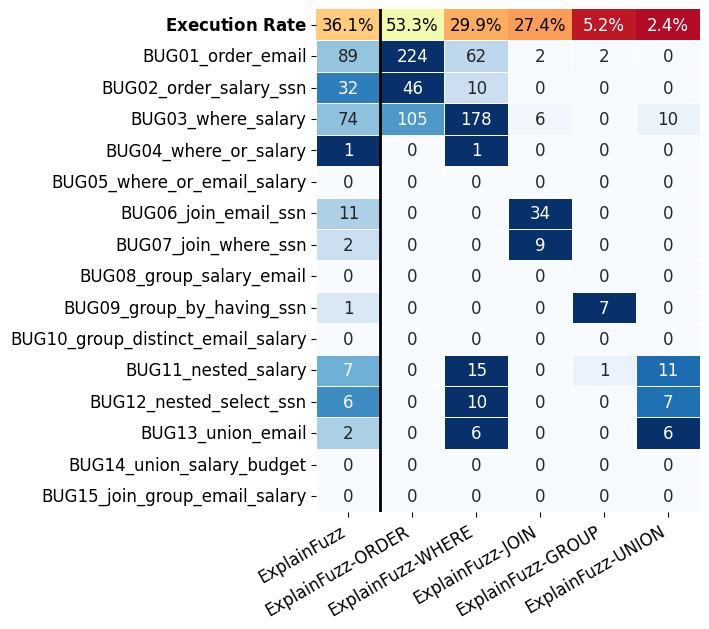

In [48]:
for domain in domains_sql:
    plot_bug_level_heatmap_with_exec(file_path_summary_conditioning_sql, domain,bug_specs_sql,order_col_sql)

#### Results per bug


In [49]:
main_domain_sql = "SQL"
main_domain_xml = "XML"

Figure saved to: data/results/figures/bug_heatmap_SQL_counts.png


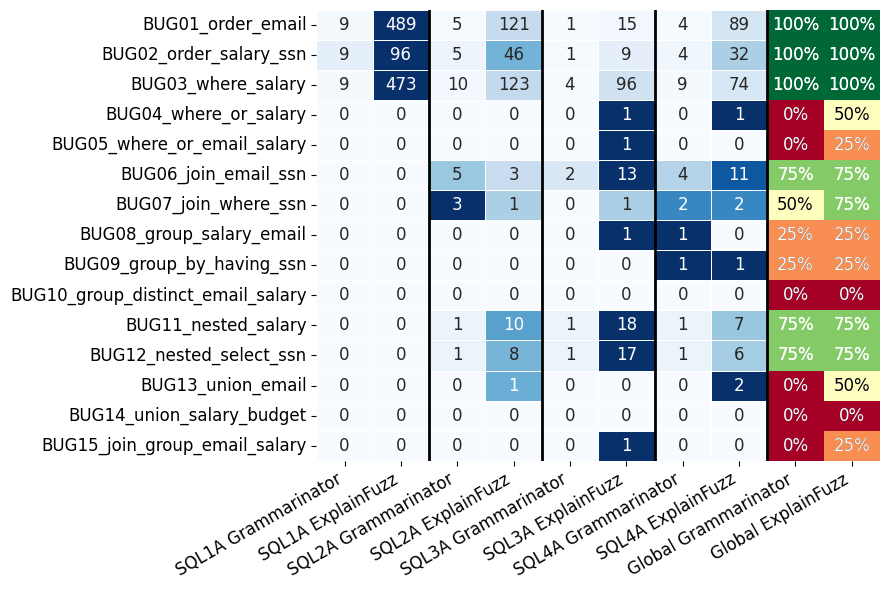

In [50]:

plot_bug_level_heatmap_counts(file_path_summary_per_bug_sql,domains_sql,bug_specs_sql,main_domain_sql)

Figure saved to: data/results/figures/bug_heatmap_XML_counts.png


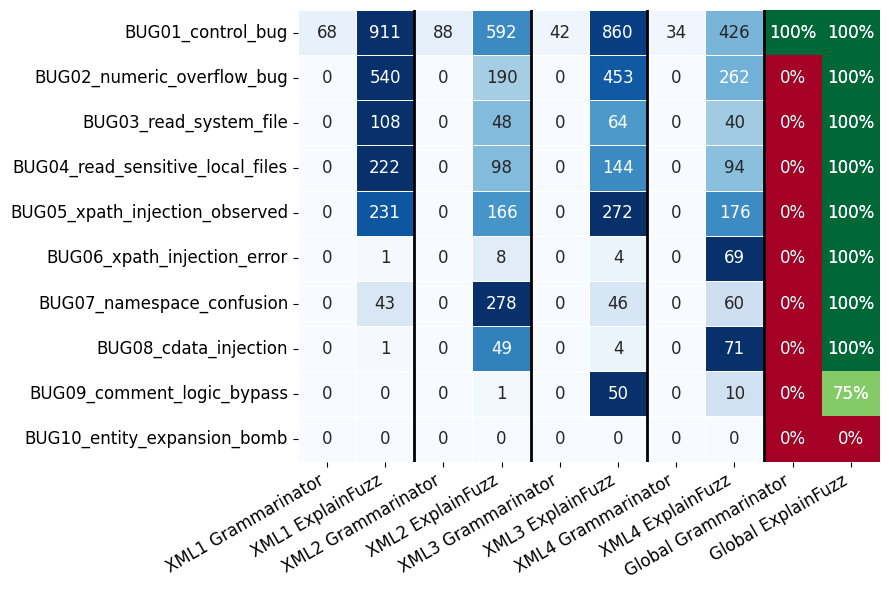

In [51]:
plot_bug_level_heatmap_counts(file_path_summary_per_bug_xml,domains_xml,bug_specs_xml,main_domain_xml)

In [52]:
metrics = [
        ("executable_rate", "Executable rate (\\%)"),
        ("coverage", "Bug coverage (\\%)"),
        ("total_triggers", "Total triggers"),
        ("total_distinct_queries", "Total triggers distinct "),
        ("explicit_sensitive", "Explicit sensitive rate (\\%)")
    ]
sql_seed_label = {"SQL-1":"Homogeneous structure","SQL-2":"Homogeneous column","SQL-3":"Small set + diverse" ,"SQL-4":"Big set + diverse"}
xml_seed_label = {"XML-1":"Homogeneous structure","XML-2":"Nested structure", "XML-3":"Comments heavy","XML-4":"Big set + diverse"}
generate_table_summary_results_multi_domain(file_path_summary_sql, file_path_summary_xml, metrics,sql_seed_label,xml_seed_label)

\begin{tabular}{c c c >{\centering\arraybackslash}p{2cm} >{\centering\arraybackslash}p{2cm} >{\centering\arraybackslash}p{2cm} >{\centering\arraybackslash}p{2cm} >{\centering\arraybackslash}p{2cm}}
\toprule
\multirow{2}{*}{\centering\textbf{Seeds}} & \multirow{2}{*}{\centering\textbf{Seeds description}} & \multirow{2}{*}{\centering\textbf{Model}} & \multirow{2}{2.1cm}{\centering\textbf{Executable rate (\%)}} & \multirow{2}{2.1cm}{\centering\textbf{Bug coverage (\%)}} & \multirow{2}{2.1cm}{\centering\textbf{Total triggers}} & \multirow{2}{2.1cm}{\centering\textbf{Total triggers distinct }} & \multirow{2}{2.1cm}{\centering\textbf{Explicit sensitive rate (\%)}} \\[3ex]
\midrule
\multirow{2}{*}{SQL-1} & \multirow{2}{*}{Homogeneous structure} &  Grammarinator & 45.1 & \textbf{20.0} & 132.0 & 27.0 & 0.0 \\
& & ExplainFuzz & \textbf{73.2} & \textbf{20.0} & \textbf{1060.0} & \textbf{1057.0} & \textbf{78.6} \\
\midrule
\multirow{2}{*}{SQL-2} & \multirow{2}{*}{Homogeneous column} &  Grammarinato

'\\begin{tabular}{c c c >{\\centering\\arraybackslash}p{2cm} >{\\centering\\arraybackslash}p{2cm} >{\\centering\\arraybackslash}p{2cm} >{\\centering\\arraybackslash}p{2cm} >{\\centering\\arraybackslash}p{2cm}}\n\\toprule\n\\multirow{2}{*}{\\centering\\textbf{Seeds}} & \\multirow{2}{*}{\\centering\\textbf{Seeds description}} & \\multirow{2}{*}{\\centering\\textbf{Model}} & \\multirow{2}{2.1cm}{\\centering\\textbf{Executable rate (\\%)}} & \\multirow{2}{2.1cm}{\\centering\\textbf{Bug coverage (\\%)}} & \\multirow{2}{2.1cm}{\\centering\\textbf{Total triggers}} & \\multirow{2}{2.1cm}{\\centering\\textbf{Total triggers distinct }} & \\multirow{2}{2.1cm}{\\centering\\textbf{Explicit sensitive rate (\\%)}} \\\\[3ex]\n\\midrule\n\\multirow{2}{*}{SQL-1} & \\multirow{2}{*}{Homogeneous structure} &  Grammarinator & 45.1 & \\textbf{20.0} & 132.0 & 27.0 & 0.0 \\\\\n& & ExplainFuzz & \\textbf{73.2} & \\textbf{20.0} & \\textbf{1060.0} & \\textbf{1057.0} & \\textbf{78.6} \\\\\n\\midrule\n\\multirow{2}

In [53]:
dataframe_to_latex_summary(file_path_summary_conditioning_sql, bug_specs_sql,file_path_summary_conditioning_xml, bug_specs_xml)

\begin{tabular}{l ccc cc}
\toprule
 & \multicolumn{3}{c}{Bug Coverage (\%)} & \multicolumn{2}{c}{Diversity vs Grammarinator} \\
\cmidrule(lr){2-4} \cmidrule(lr){5-6}
Seed & Grammarinator & ExplainFuzz & EF+Cond & ExplainFuzz & EF+Cond \\
\midrule
SQL1A & 17.6\% & 17.6\% & 33.3\% & +79.83 & +76.37 \\
SQL2A & 47.1\% & 43.1\% & 86.7\% & +20.92 & +66.17 \\
SQL3A & 35.3\% & 47.1\% & 66.7\% & +7.61 & +27.46 \\
SQL4A & 41.2\% & 51.0\% & 66.7\% & +15.56 & +38.23 \\
\midrule
\textbf{Global} & \textbf{66.7}\% &\textbf{93.3}\% & \textbf{86.7}\% & \textbf{+30.98} & \textbf{+52.06} \\
\midrule
XML1 & 10.0\% & 66.7\% & 100.0\% & +66.28 & +215.79 \\
XML2 & 10.0\% & 86.7\% & 100.0\% & +48.64 & +173.13 \\
XML3 & 10.0\% & 86.7\% & 100.0\% & +70.56 & +168.67 \\
XML4 & 10.0\% & 90.0\% & 100.0\% & +49.88 & +163.53 \\
\midrule
\textbf{Global} & \textbf{10.0}\% &\textbf{100.0}\% & \textbf{100.0}\% & \textbf{+58.84} & \textbf{+180.28} \\
\bottomrule
\end{tabular}


'\\begin{tabular}{l ccc cc}\n\\toprule\n & \\multicolumn{3}{c}{Bug Coverage (\\%)} & \\multicolumn{2}{c}{Diversity vs Grammarinator} \\\\\n\\cmidrule(lr){2-4} \\cmidrule(lr){5-6}\nSeed & Grammarinator & ExplainFuzz & EF+Cond & ExplainFuzz & EF+Cond \\\\\n\\midrule\nSQL1A & 17.6\\% & 17.6\\% & 33.3\\% & +79.83 & +76.37 \\\\\nSQL2A & 47.1\\% & 43.1\\% & 86.7\\% & +20.92 & +66.17 \\\\\nSQL3A & 35.3\\% & 47.1\\% & 66.7\\% & +7.61 & +27.46 \\\\\nSQL4A & 41.2\\% & 51.0\\% & 66.7\\% & +15.56 & +38.23 \\\\\n\\midrule\n\\textbf{Global} & \\textbf{66.7}\\% &\\textbf{93.3}\\% & \\textbf{86.7}\\% & \\textbf{+30.98} & \\textbf{+52.06} \\\\\n\\midrule\nXML1 & 10.0\\% & 66.7\\% & 100.0\\% & +66.28 & +215.79 \\\\\nXML2 & 10.0\\% & 86.7\\% & 100.0\\% & +48.64 & +173.13 \\\\\nXML3 & 10.0\\% & 86.7\\% & 100.0\\% & +70.56 & +168.67 \\\\\nXML4 & 10.0\\% & 90.0\\% & 100.0\\% & +49.88 & +163.53 \\\\\n\\midrule\n\\textbf{Global} & \\textbf{10.0}\\% &\\textbf{100.0}\\% & \\textbf{100.0}\\% & \\textbf{+58.84} &